In [ ]:
import numpy as np
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
import matplotlib.animation as animation
from matplotlib.patches import ConnectionPatch

import cmocean
import xarray as xr
from glob import glob
import cartopy
from cartopy.crs import Geodetic, PlateCarree, Stereographic
import warnings

import pandas as pd
import seaborn as sns

warnings.simplefilter("ignore")

# Set Parameters

- Maps
    - [x] Monats Aufenthaltswahrscheinlichkeiten
    - [x] Jahres Aufenthaltswahrscheinlichkeiten
    - [x] Linen zwischen Stationen
- Connectivitätsmatrix
    - [x] Monats Averages (logscale)
    - [x] Jahres Averages (logscale)
    - [ ] Einzelne Jahre

In [ ]:
# Set the basic parameters
years = np.arange(2016,2025)
location_names = [
    "Speicherkoog", "KB03", "SW08", "Wilhelmshaven", "GB96", "H21",
    "Boknis_Eck", "Gdynia", "Riga", "IU7_c", "LL17_c", "Finland",
    "BB23", "BB36", "Speicherkoog_Außen", "Wilhelmshaven_Außen",
]
lats = [
    54.0929, 54.692, 54.413, 53.513, 56.54, 54.666,
    54.5169, 54.5829, 57.3911, 59.489, 59.02, 59.77,
    55.1751, 54.575, 54.11, 53.637,
]
lons = [
    8.9487, 10.1035, 11.617, 8.149, 19.5809, 13.0224,
    10.034, 18.6042, 23.8588, 21.2021, 21.0478, 23.2663,
    15.4352, 16.001, 8.5, 8.15,
]

df_sample_sites = pd.DataFrame(
    data={"lon":lons, "lat":lats},
    index=location_names,
)
df_locations_sorted = df_sample_sites.sort_values(by="lon")
location_names_sorted = df_locations_sorted.index.values.tolist()
 
number_sites = len(location_names)
number_years = len(years)

dist = 10

lonlim = (0,30)
latlim = (52,62)

title_months = ["Jun to Oct", 
    "Jan", "Feb", "Mar", "Apr", "May", "June", 
    "July", "August", "September", "October", "November", "December"
    ]

In [3]:
ndays = (np.datetime64("2016-11-01", "D") - np.datetime64("2016-06-01", "D")).astype("int")
ntimestepday = 24*4
ndayslife = 28
nparticles = 1000
ntotal = ndays * number_years * ntimestepday * ndayslife * number_sites * nparticles
n30d = 30 * number_years * ntimestepday * ndayslife * number_sites * nparticles
n31d = 31 * number_years * ntimestepday * ndayslife * number_sites * nparticles

In [4]:
# Visual parameters
suptitle_size = 20
title_size = 16
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
lonmid = np.mean(extent[:2])
latmid = np.mean(extent[:2])
map_projection = Stereographic(
    central_longitude=lonmid, central_latitude=latmid,
    )


In [5]:
input_path = Path("/gxfs_work/geomar/smomw597/2025_copepods/output/")
figure_outpath = Path("/gxfs_work/geomar/smomw597/2025_copepods/Figures/")

# Functions

In [6]:
def sort_cmatrix(matrix_in):
    matrix = pd.DataFrame(
        matrix_in,
        index=location_names,
        columns=location_names,
    )
    matrix = matrix[location_names_sorted + [c for c in matrix.columns if c not in location_names_sorted]]
    return matrix.reindex(location_names_sorted)

In [7]:
matrix_list = sorted(Path(input_path).glob(f"Connectivity/connectivity_matrices_2*"))
print(len(matrix_list))

for i, matrix_link in enumerate(matrix_list): 
    if i == 0:
        connectivity_matrix = np.load(matrix_link, allow_pickle=True).all()
    else:
        temp_matrices = np.load(matrix_link, allow_pickle=True,).all()
        for key, temp_matrix in temp_matrices.items():
            if key in list(connectivity_matrix.keys()):
                connectivity_matrix[key] = connectivity_matrix[key] + temp_matrix
            else:
                connectivity_matrix[key] = temp_matrix

144


In [8]:
total_connectivity_matrix = np.zeros_like(connectivity_matrix[2016,6])
for i, matrix in connectivity_matrix.items():
    total_connectivity_matrix = total_connectivity_matrix + matrix

In [9]:
monthly_connectivity_matrix = {}
for (i_y, i_m), matrix in connectivity_matrix.items():
    if i_y == 2016:
        monthly_connectivity_matrix[i_m] = matrix
    else:
        monthly_connectivity_matrix[i_m] = monthly_connectivity_matrix[i_m] + matrix

In [10]:
def map_sites(ax):
    return ax.scatter(
        lons, lats,
        transform=Geodetic(),
        c="magenta", s=25,
    )

In [11]:
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [12]:
def make_cbar(fig, ax, hist):
    cax = fig.add_axes(
        [
            ax.get_position().x1+0.01,
            ax.get_position().y0, 0.02,
            ax.get_position().height
        ]
    )
    return plt.colorbar(hist, cax=cax,)

# Connectivity Matrices

In [16]:
df_cmatrix_total = sort_cmatrix(total_connectivity_matrix)
connectivity_min = 1
for m, matrix in monthly_connectivity_matrix.items():
    if m in [6,9]:
        matrix = sort_cmatrix(matrix/n30d*100)
    elif m in [7,8,10]:
        matrix = sort_cmatrix(matrix/n31d*100)
    monthly_connectivity_matrix[m] = matrix
    mask = matrix==0
    matrix_min = matrix.mask(mask).min().min()
    if matrix_min < connectivity_min:
        connectivity_min = matrix_min
df_cmatrix_total_pc = df_cmatrix_total/ntotal*100

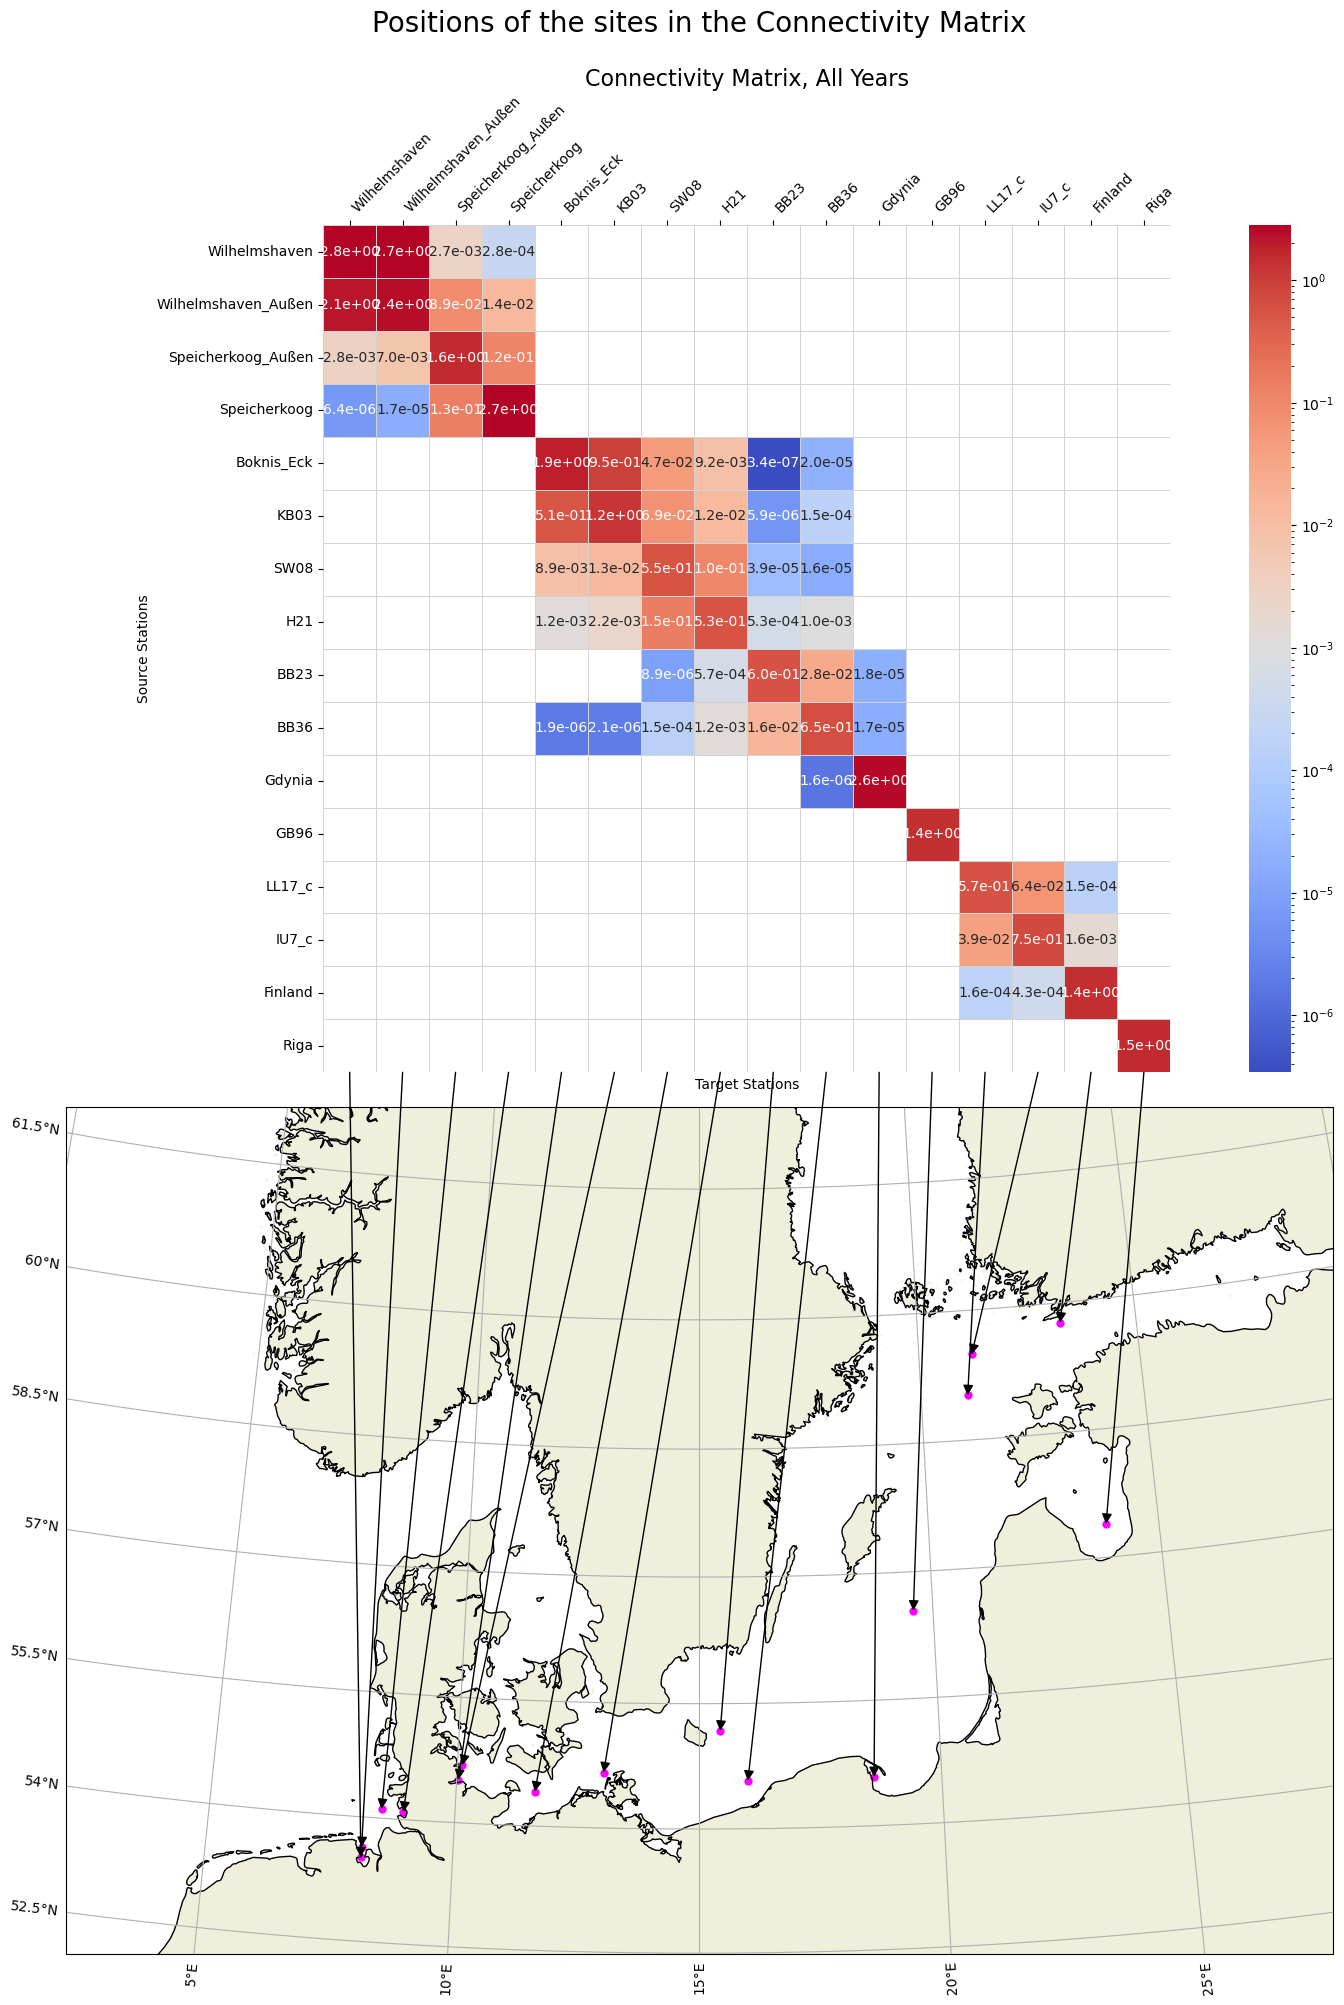

In [17]:
matrix = df_cmatrix_total_pc
mask = matrix == 0
fig = plt.figure(figsize=(16,20))
fig.suptitle(
    "Positions of the sites in the Connectivity Matrix",
    y=1, size=suptitle_size,
    )

ax_matrix = fig.add_subplot(2,1,1)
ax_matrix.set_title(
    "Connectivity Matrix, All Years",
    size=title_size
    )
sns.heatmap(
    matrix,
    annot=True, 
    fmt=".1e",
    cmap="coolwarm", 
    linecolor="lightgrey",
    cbar=True,
    mask=mask,
    linewidths=0.5,
    norm=LogNorm(),
    square=True,
    ax=ax_matrix,
)
ax_matrix.xaxis.tick_top()
ax_matrix.set_xticklabels(ax_matrix.get_xticklabels(), rotation=45, ha='left')
ax_matrix.set_xlabel("Target Stations")
ax_matrix.set_ylabel("Source Stations")

ax_map = fig.add_subplot(212, projection=map_projection,)
basemap(ax_map)
map_sites(ax_map)

# Connecting lines between Plots
for i, lon in enumerate(df_locations_sorted.lon):
    lat = df_locations_sorted.lat[i]
    pos_map = map_projection.transform_point(lon, lat, PlateCarree())
    con = ConnectionPatch(
        xyA=(i+0.5,16), coordsA=ax_matrix.transData, #Positions below Matrix
        xyB=pos_map, coordsB=ax_map.transData, #Positions on map
        zorder=90,
        color="k",
    )
    con.set_arrowstyle("-|>,head_length=0.6,head_width=0.3")
    fig.add_artist(con)

plt.tight_layout()
plt.savefig(Path(figure_outpath,"Overview.jpg"), format="png")
plt.show()

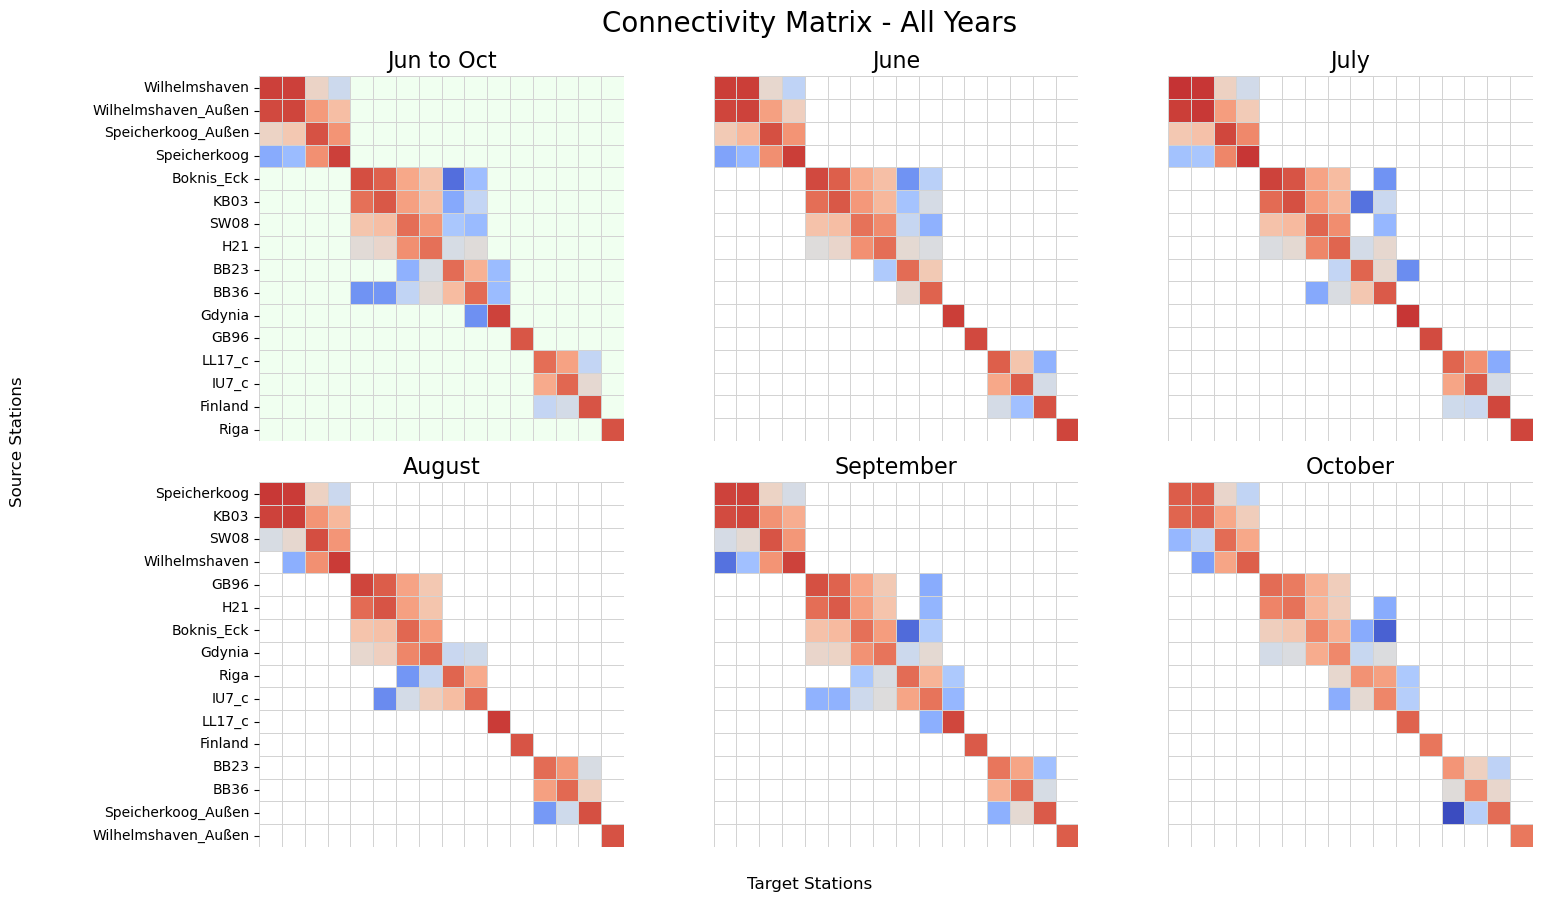

In [18]:
fig = plt.figure(figsize=(16, 9))
fig.suptitle("Connectivity Matrix - All Years", size=suptitle_size)
fig.supylabel("Source Stations", x=0)
fig.supxlabel("Target Stations", y=0)

ax = fig.add_subplot(231, fc="#f0fff0")
ax.set_title(title_months[0], size=title_size)
matrix = df_cmatrix_total_pc
mask = matrix == 0
total_cm = sns.heatmap(
    matrix,
    annot=False, 
    fmt=".1e",
    cmap="coolwarm", 
    linecolor="lightgrey",
    mask = mask,
    square=True,
    linewidths=0.5,
    norm=LogNorm(vmin=matrix_min, vmax=10,),
    xticklabels=False,
    cbar=False,
)

for month, matrix in monthly_connectivity_matrix.items():
    ax = fig.add_subplot(int(str(f"23{month-4}")))
    mask = matrix == 0
    hm = sns.heatmap(
        matrix,
        annot=False, 
        fmt=".1e",
        cmap="coolwarm", 
        linecolor="lightgrey",
        mask=mask,
        square=True,
        linewidths=0.5,
        norm=LogNorm(vmin=matrix_min, vmax=10,),
        xticklabels=False,
        cbar=False,
    )
    if month == 8:
        hm.set_yticklabels(location_names)
    else:
        plt.yticks([])
    ax.set_title(title_months[month], size=title_size)
plt.tight_layout()
plt.savefig(Path(figure_outpath,"ConnectivityMatricesMonthlyComparrison.jpg"), format="png")
plt.show()

In [19]:
def showConnectivityMatrix(matrix, month = 0, fn = None):
    if type(matrix) == type({}) and month in np.arange(6,11):
        matrix = matrix[month]
    elif type(matrix) == type({}) and month not in np.arange(6,11):
        return "Please enter a valid month between 6 and 11"
    mask = matrix == 0
    fig = plt.figure(figsize=(16, 14))
    fig.suptitle(
        f"Connectivity Matrix ({title_months[month]}, All Years)",
        size=suptitle_size,
        )
    ax = fig.add_subplot()
    sns.heatmap(
        matrix,
        annot=True, 
        square=True,
        fmt=".1e",
        cmap="coolwarm", 
        linecolor="lightgrey",
        mask = mask,
        linewidths=0.5,
        norm=LogNorm(vmin=matrix_min, vmax=10,),
        cbar_kws={'label': 'Percentage of connected particles',"shrink":0.83},
        cbar=True,
        ax=ax,
    )
    ax.xaxis.tick_top()
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, va="top")
    ax.set_xlabel("Target Stations")
    ax.set_ylabel("Source Stations")
    plt.tight_layout()
    if fn != None:
        plt.savefig(Path(figure_outpath, fn), format="png")
    return plt.show()

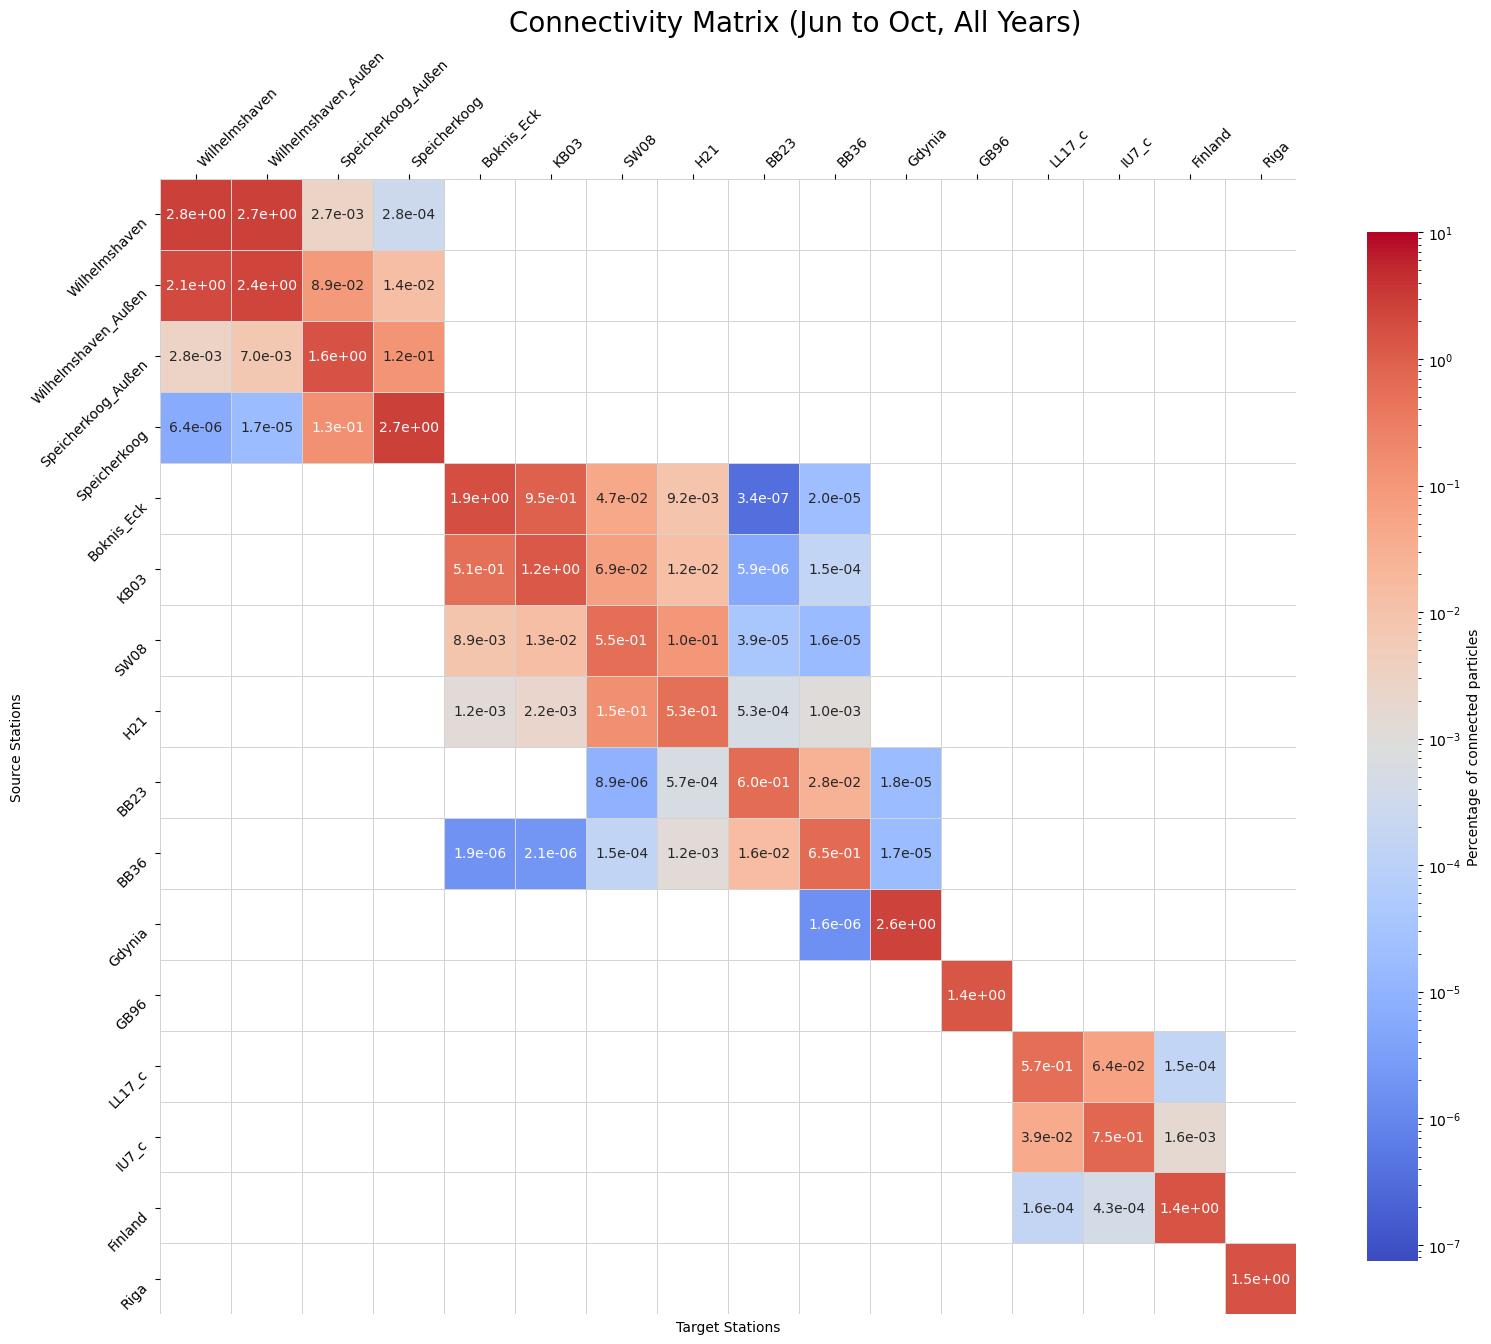

In [20]:
showConnectivityMatrix(
    df_cmatrix_total_pc,
    # fn = "ConnectivityMatrixTotal.png",
    )

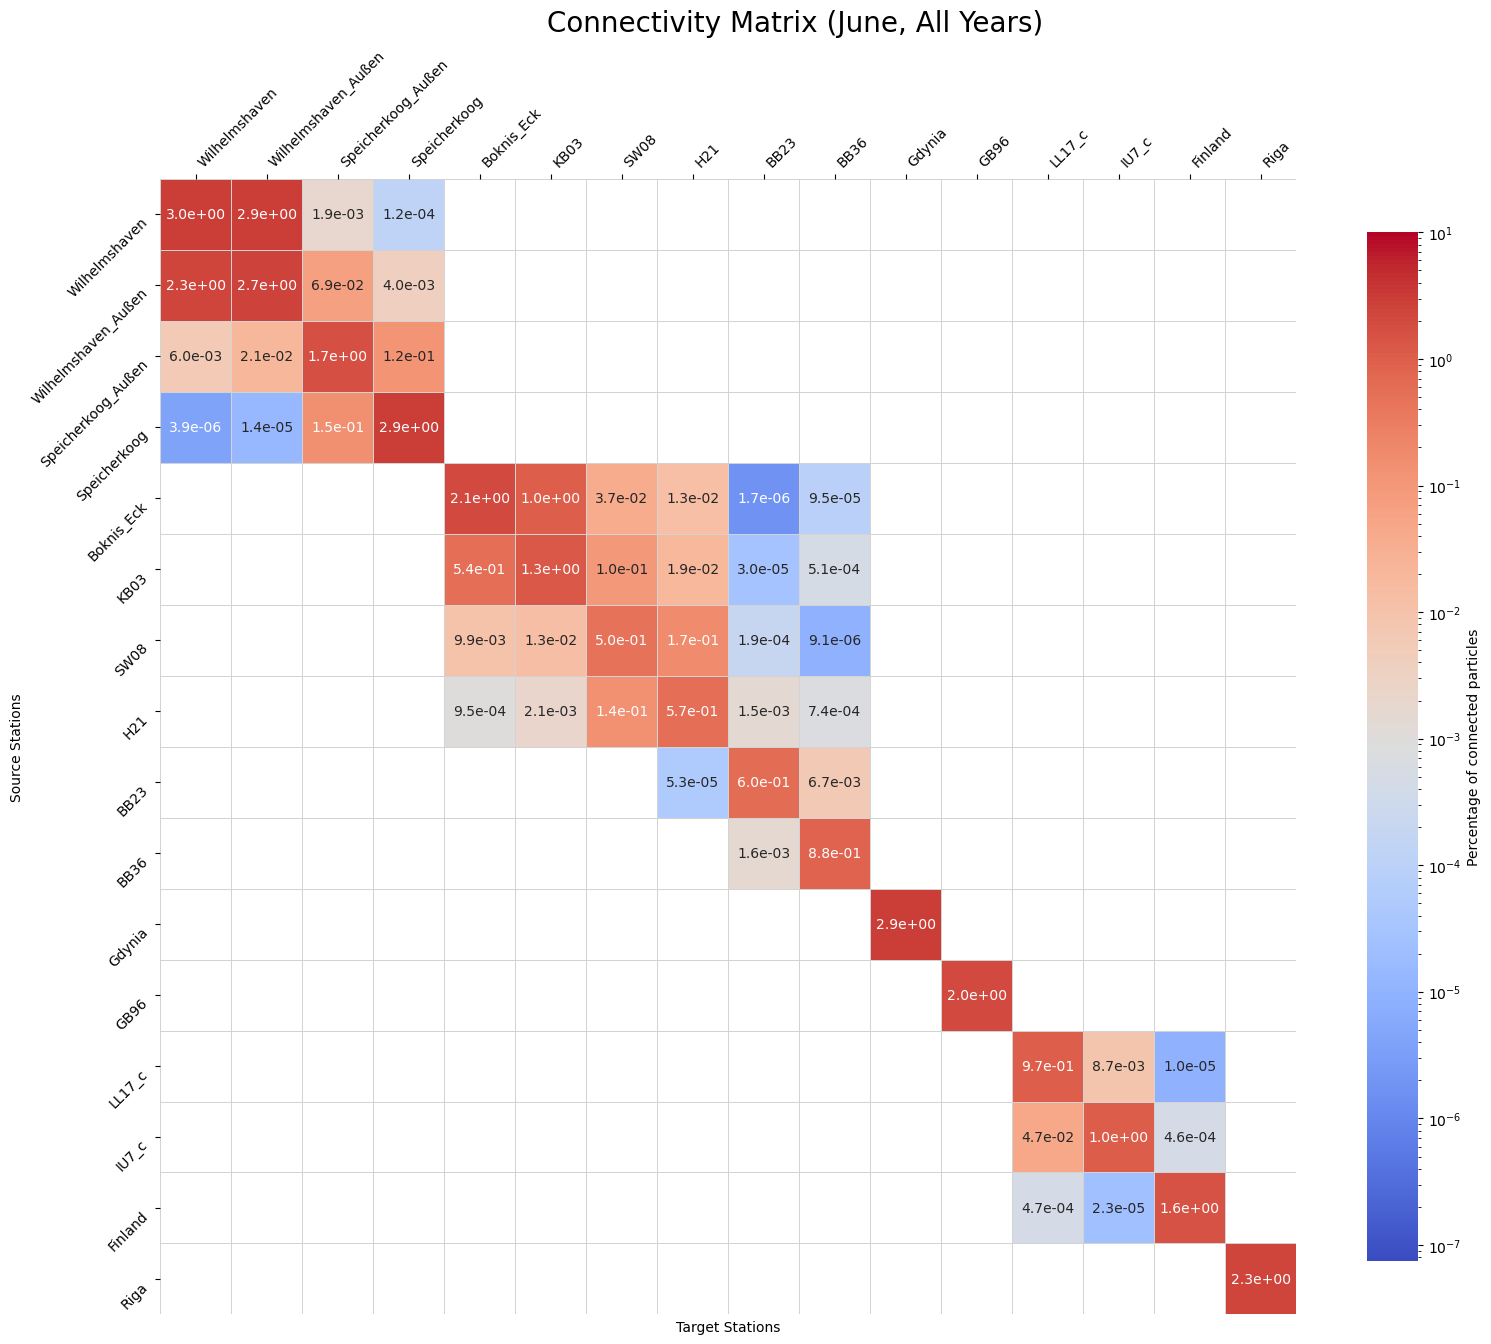

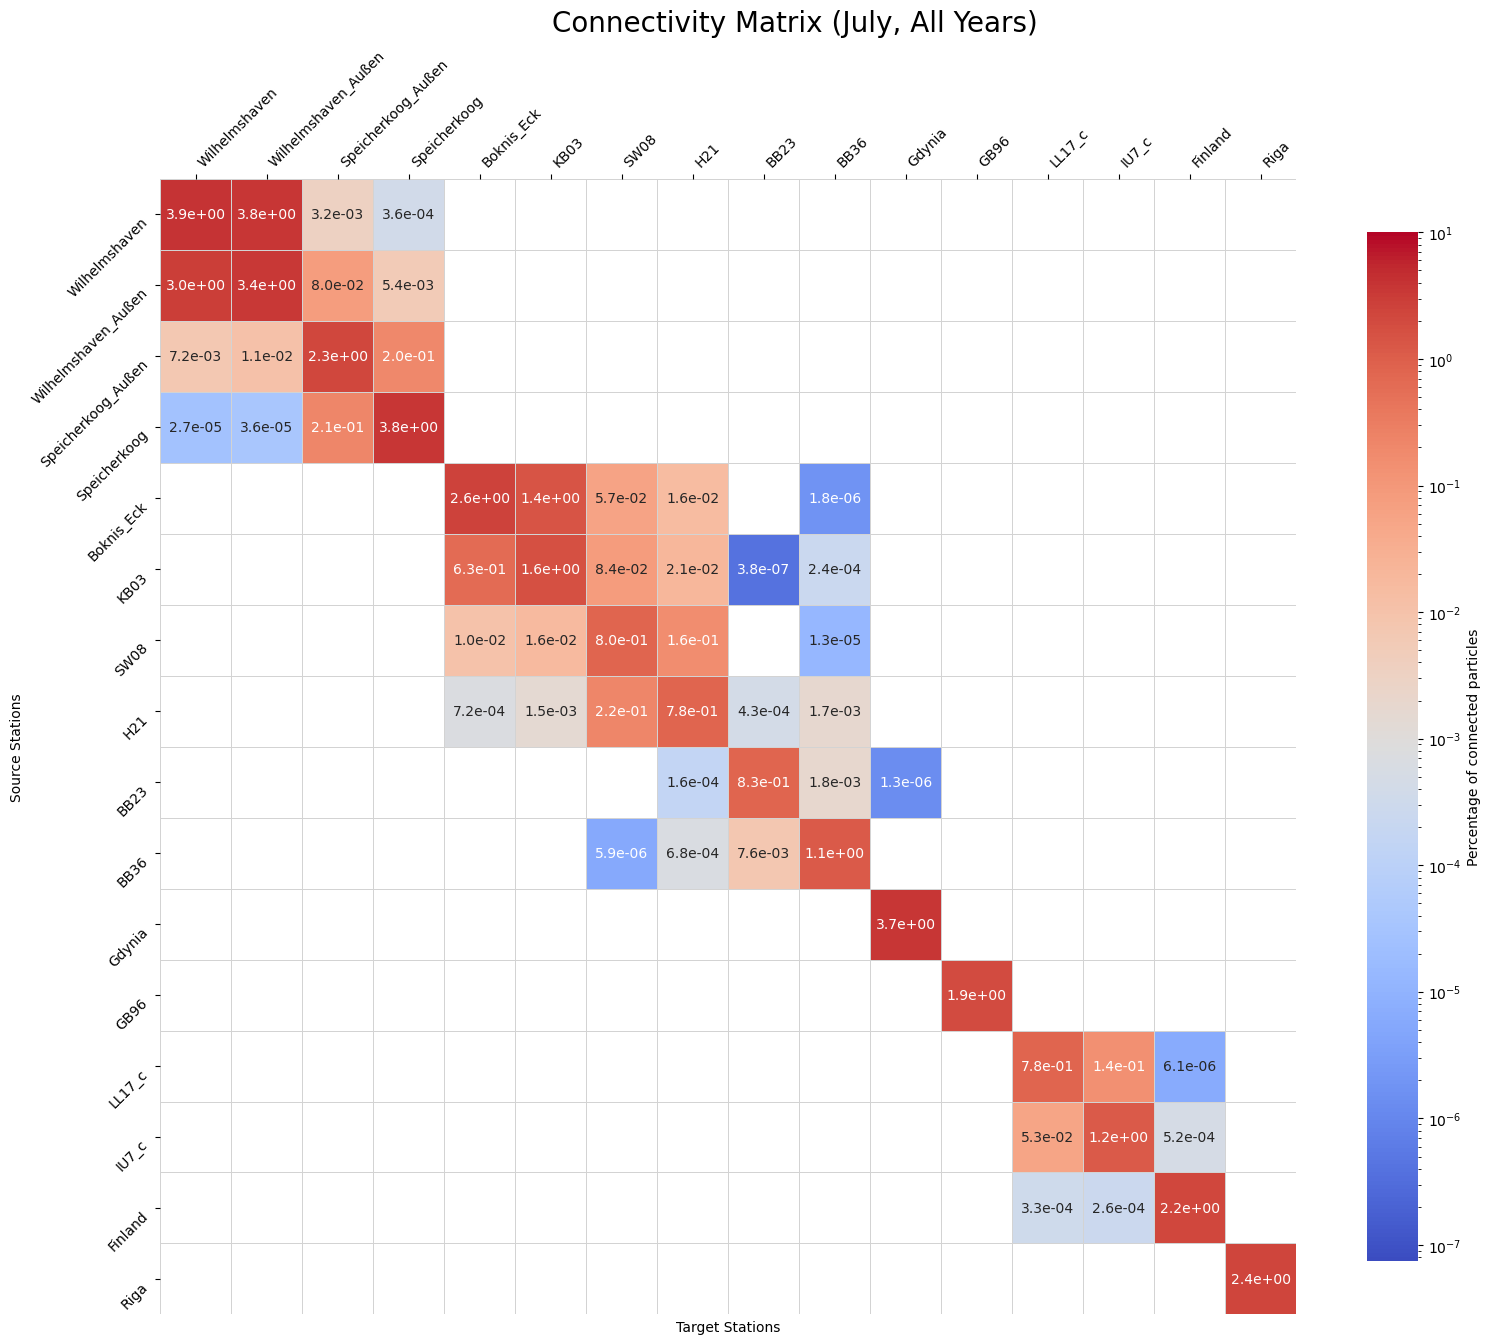

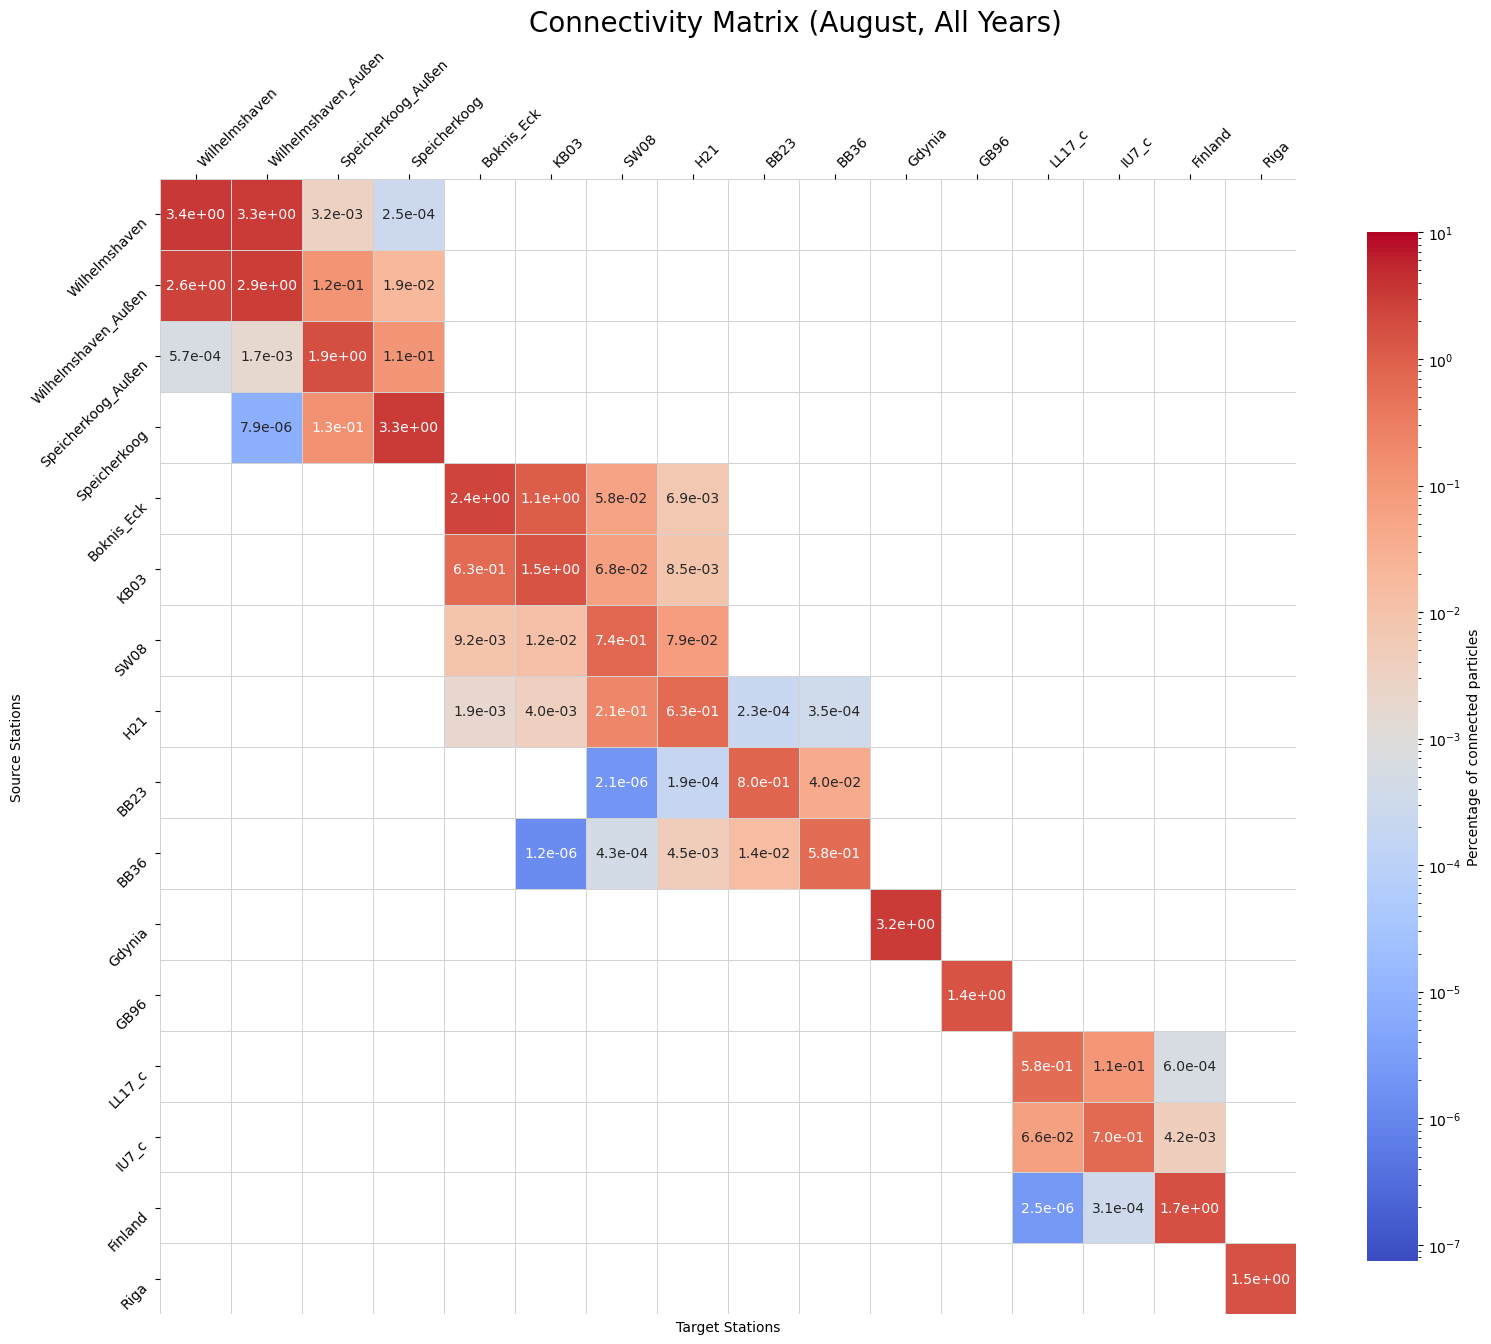

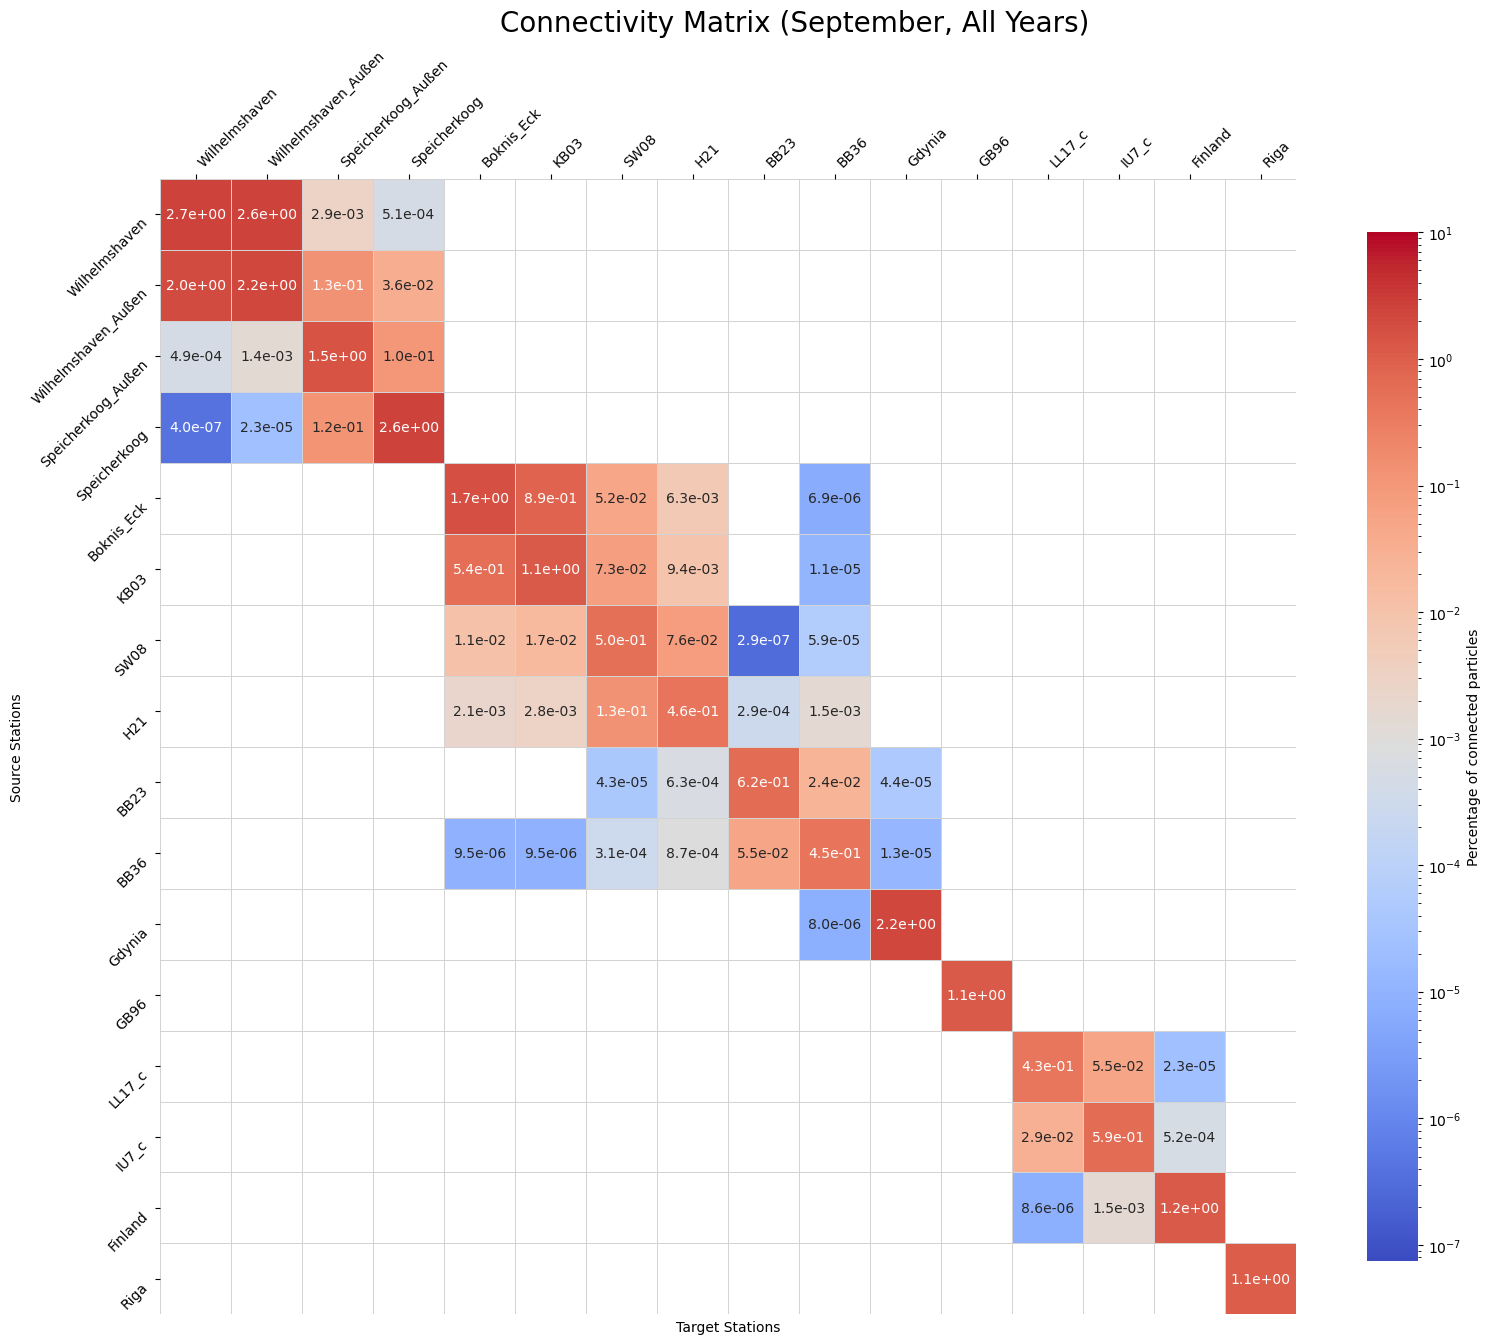

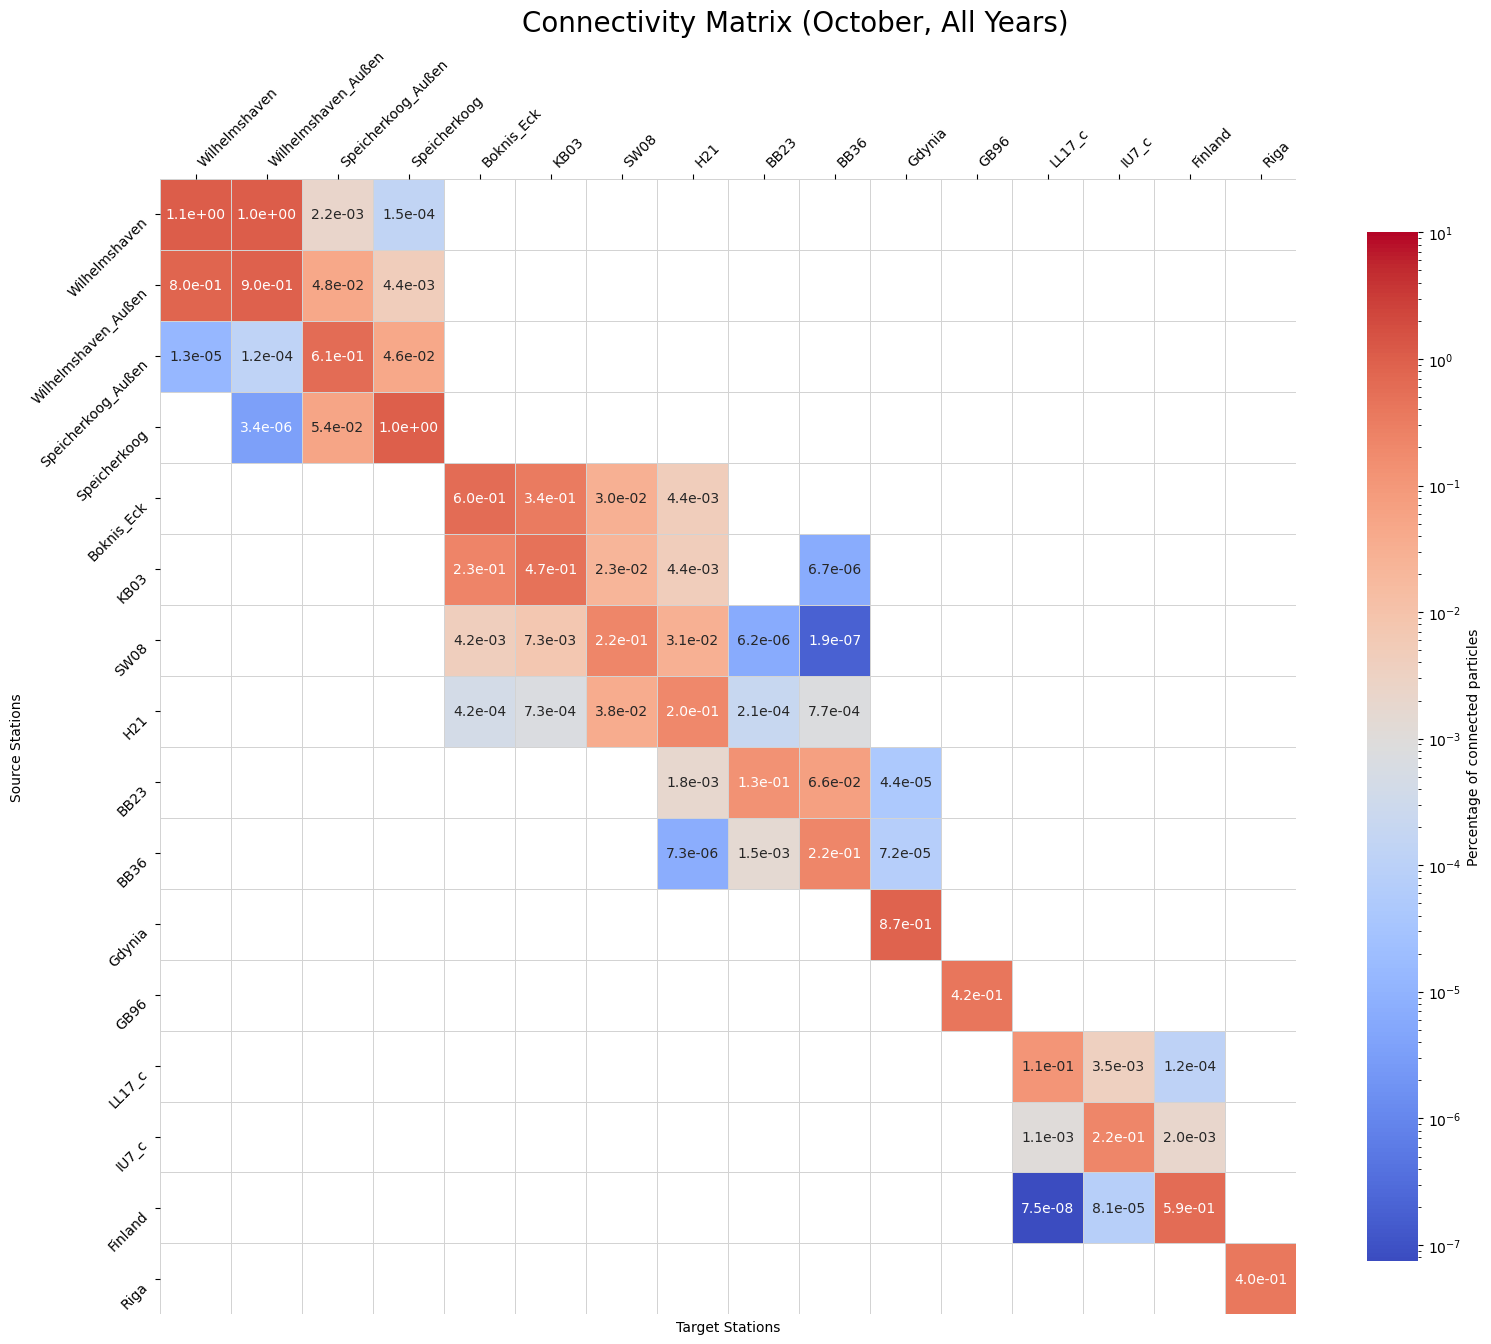

In [21]:
for m in np.arange(6,11):
    showConnectivityMatrix(monthly_connectivity_matrix, m,
    # fn=f"ConnectivityMatrix{title_months[m]}.png"
    )

# Maps

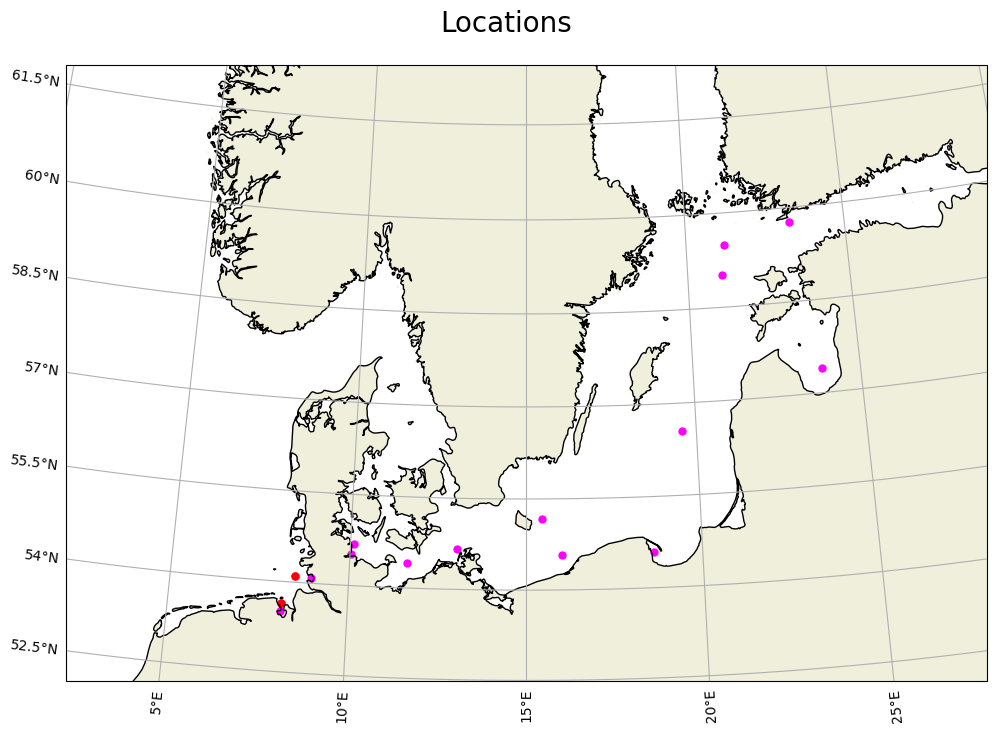

In [ ]:
fig = plt.figure(figsize=mapsize)
fig.suptitle("Locations", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
map_sites(ax_map)
# Add the red dots for the non sampled points
ax_map.scatter(
    df_locations_sorted.lon[1:3].values,
    df_locations_sorted.lat[1:3].values,
    transform=Geodetic(),
    c="r", s=25,
    )
plt.savefig(Path(figure_outpath, "EmptyMap.png"), format="png")
plt.show()

## Heatmaps

In [22]:
nbins = 100
lonbins = np.linspace(0,30,nbins)
latbins = np.linspace(50,65,nbins)

In [ ]:
lognorm = LogNorm(vmin=1, vmax=1e9)

In [25]:
# define the colormap
cmap_discrete = plt.get_cmap('viridis')  
# force the first color entry to be invisible
cmap_discrete.set_under(color="#00000000")
# resample the colormap into 9 discrete steps
cmap_discrete = cmap_discrete.resampled(9)

### Total

In [53]:
hist_total_file_list = sorted(Path(input_path).glob(f"hist/total/hist2d*"))
hist_total = np.zeros((nbins,nbins))
for hist_file in hist_total_file_list:
    hist_total = hist_total + np.load(hist_file)
hist_total = hist_total.T

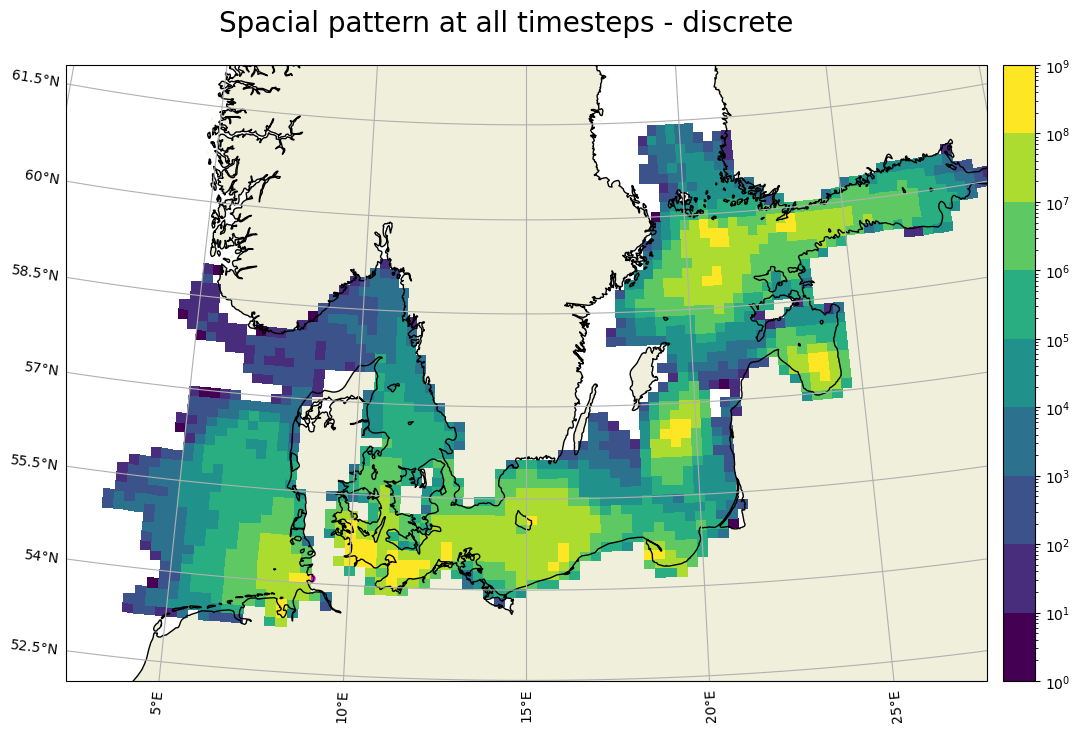

In [54]:
# Spacial heatmap - discrete
fig = plt.figure(figsize=mapsize)
fig.suptitle("Spacial pattern at all timesteps - discrete", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
map_sites(ax_map)
hist = ax_map.pcolormesh(
    lonbins, latbins,
    hist_total,
    norm=lognorm,
    transform=PlateCarree(),
    cmap=cmap_discrete,
)
make_cbar(fig, ax_map, hist)
plt.savefig(Path(figure_outpath,"HeatmapTotalDiscrete.png"), format="png")
plt.show()

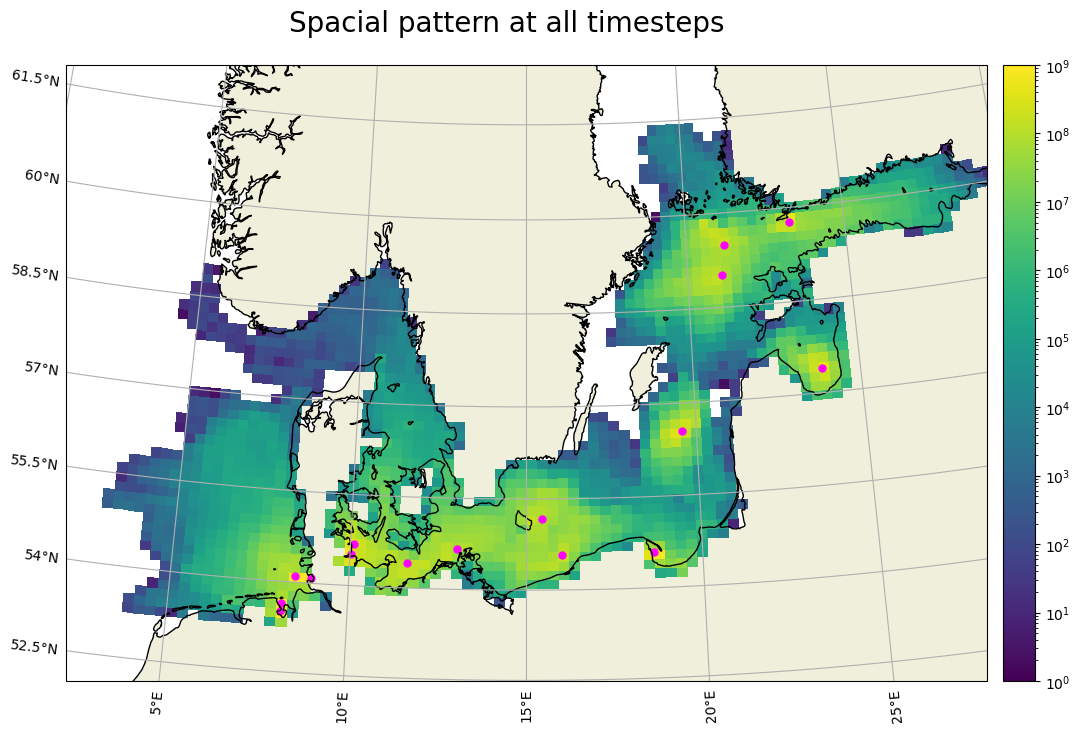

In [28]:
fig = plt.figure(figsize=mapsize)
fig.suptitle("Spacial pattern at all timesteps", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
hist = ax_map.pcolormesh(
    lonbins, latbins,
    hist_total,
    norm=lognorm,
    transform=PlateCarree(),
    cmap="viridis",
)
map_sites(ax_map)
cax = make_cbar(fig, ax_map, hist)
plt.savefig(Path(figure_outpath,"HeatmapTotal.png"), format="png")
plt.show()

### Monthly

In [30]:
hist_monthly_file_list = sorted(Path(input_path).glob(f"hist/monthly/hist2d*"))
print(len(hist_monthly_file_list))

144


In [31]:
hist_monthly_raw = np.load(hist_monthly_file_list[0], allow_pickle=True).all()
monthly_histogram = {}
for m in np.arange(6,11):
    monthly_histogram[m] = np.zeros_like(hist_monthly_raw[6])
    
for hist_monthly_file in hist_monthly_file_list:
    hist = np.load(hist_monthly_file, allow_pickle=True).all()
    for m, data in hist.items():
        monthly_histogram[m] = monthly_histogram[m] + data
for i, hist in monthly_histogram.items():
    monthly_histogram[i] = hist.T

In [32]:
hist_monthly_raw = np.load(hist_monthly_file_list[0], allow_pickle=True).all()
monthly_histogram = (
    {
        6:np.zeros_like(hist_monthly_raw[6]),
        7:np.zeros_like(hist_monthly_raw[7]),
        8:np.zeros_like(hist_monthly_raw[8]),
        9:np.zeros_like(hist_monthly_raw[9]),
        10:np.zeros_like(hist_monthly_raw[10]),
    }
)
monthly_histogram = {}
for m in np.arange(6,11):
    for s in np.arange(0,16):
        monthly_histogram[m,s] = np.zeros_like(hist_monthly_raw[6])
monthly_histogram
for hist_monthly_file in hist_monthly_file_list:
    site_counter = int(str(hist_monthly_file)[-6:-4])
    # year = int(str(hist_monthly_file)[-12:-8])
    hist = np.load(hist_monthly_file, allow_pickle=True).all()
    for m, data in hist.items():
        monthly_histogram[m, site_counter] = monthly_histogram[m, site_counter] + data
for (m, s), hist in monthly_histogram.items():
    monthly_histogram[m,s] = hist.T

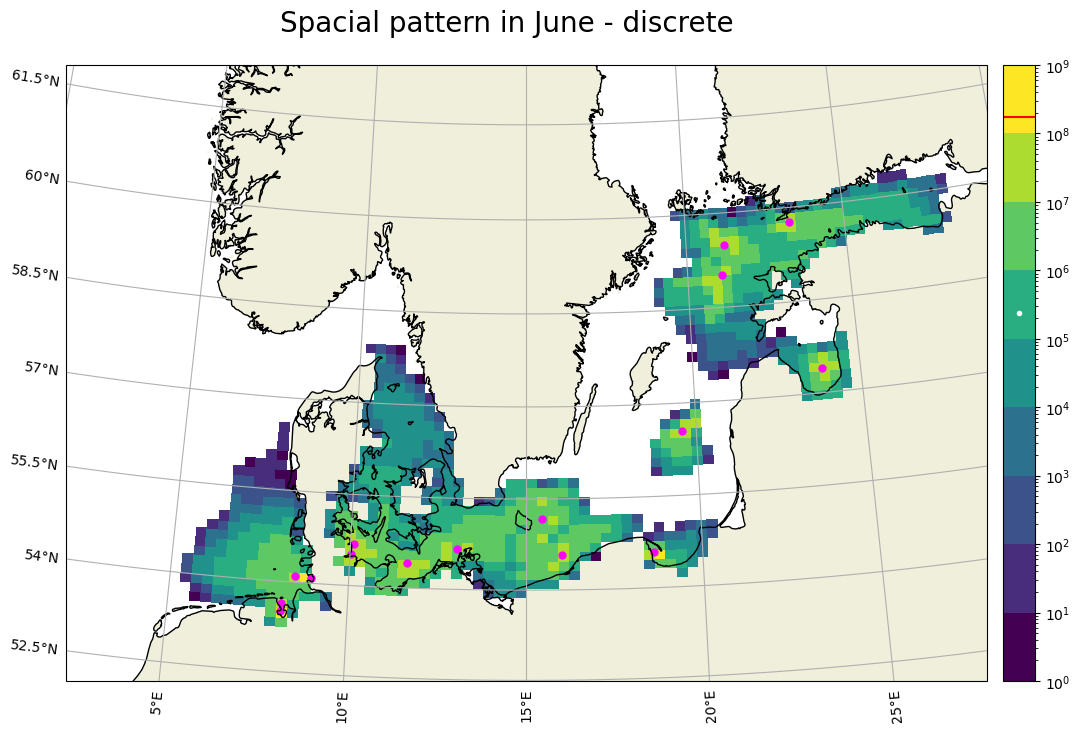

In [33]:
def heatmap(data, month=None, site=None, vmax = None, fn=None, isdiscrete=False):
    if (
        (type(data) == type({})) &
        (month in np.arange(6,11)) & 
        (site in np.arange(0,16))
     ):
        data = data[month, site]
    if site == None:
        dummy = np.zeros_like(data[month, 0])
        for s in np.arange(0,16):
            dummy = dummy + data[month, s]
        data = dummy
    if isdiscrete == True:
        cmap = cmap_discrete
        title = f"Spacial pattern in {title_months[month]} - discrete"
    else:
        cmap = "viridis"
        title = f"Spacial pattern in {title_months[month]}"

    fig = plt.figure(figsize=mapsize)
    fig.suptitle(title, size=suptitle_size, y=0.95)
    ax_map = fig.add_subplot(projection=map_projection,)
    basemap(ax_map)
    hist = ax_map.pcolormesh(
        lonbins, latbins,
        data,
        norm=lognorm,
        transform=PlateCarree(),
        cmap=cmap,
    )
    map_sites(ax_map)
    if site != None:
        ax_map.scatter(
            lons[site], lats[site],
            transform=Geodetic(),
            zorder=100,
            c="r", s=25, edgecolors="k",
        )
    cbar = make_cbar(fig, ax_map, hist)
    # mark max on cbar
    cbar.ax.axhline(np.nanmax(data), c='r')
    cbar.ax.plot(0.5, np.nanmean(data), 'w.', label="mean")
    cbar.ax.plot(0.5, np.nanmedian(data), 'w_', label="median")
    if fn != None:
        plt.savefig(Path(figure_outpath,fn), format="png")
    plt.show()
heatmap(monthly_histogram, month=6, site=None, isdiscrete=True)

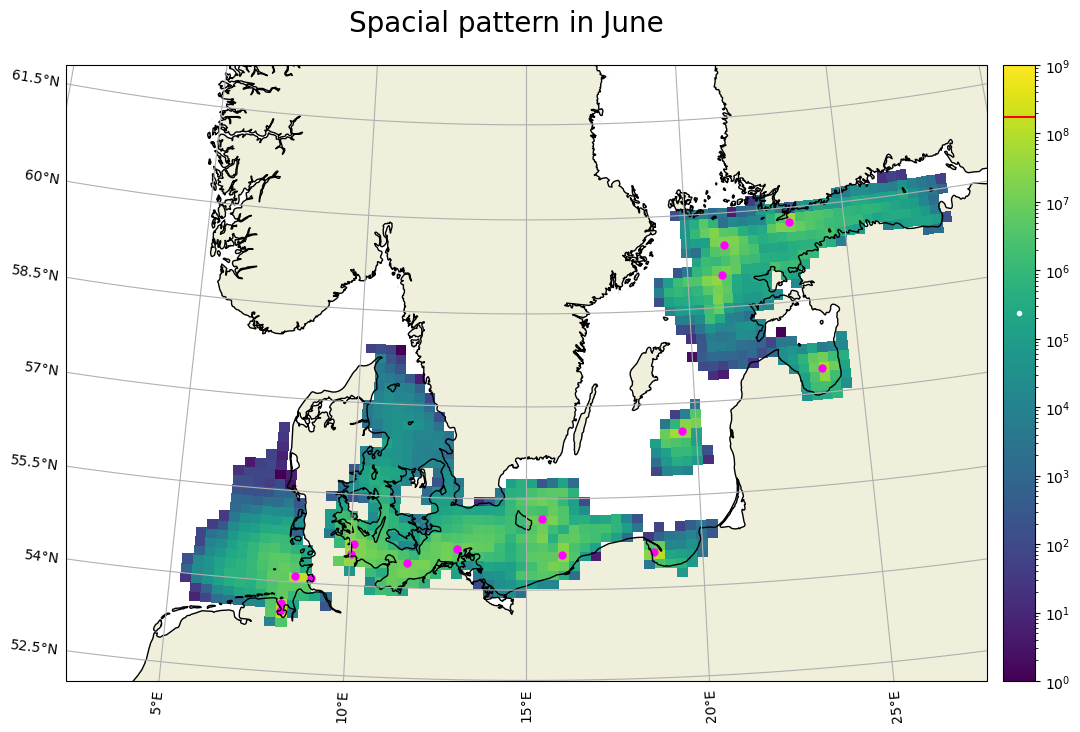

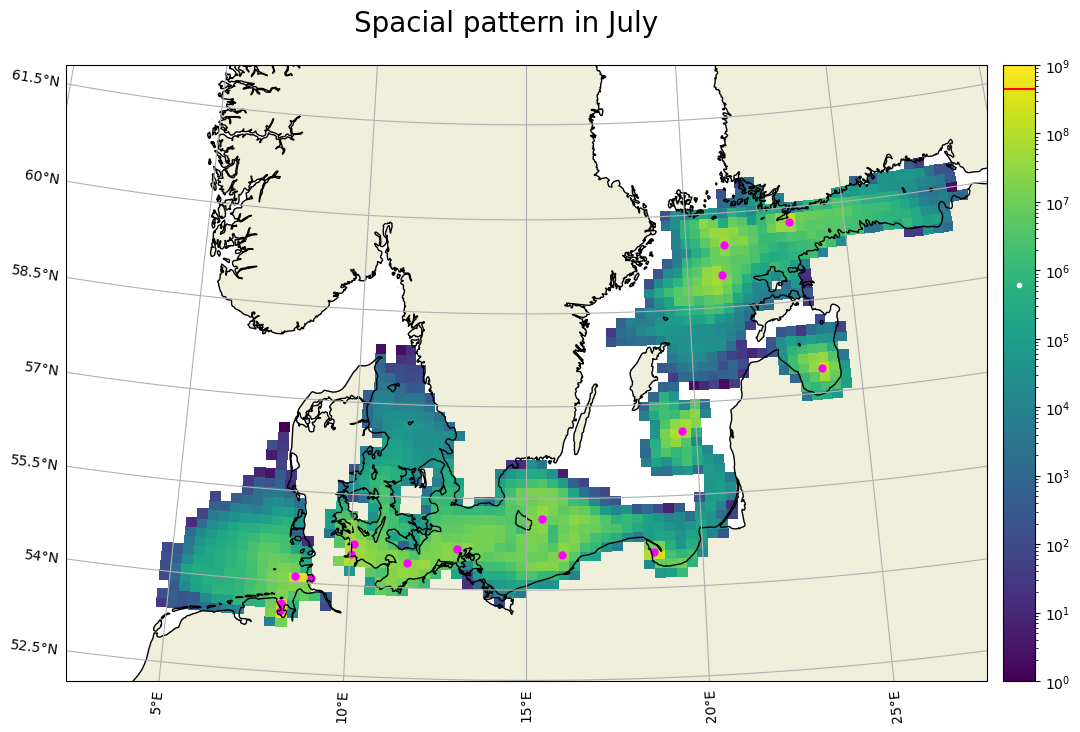

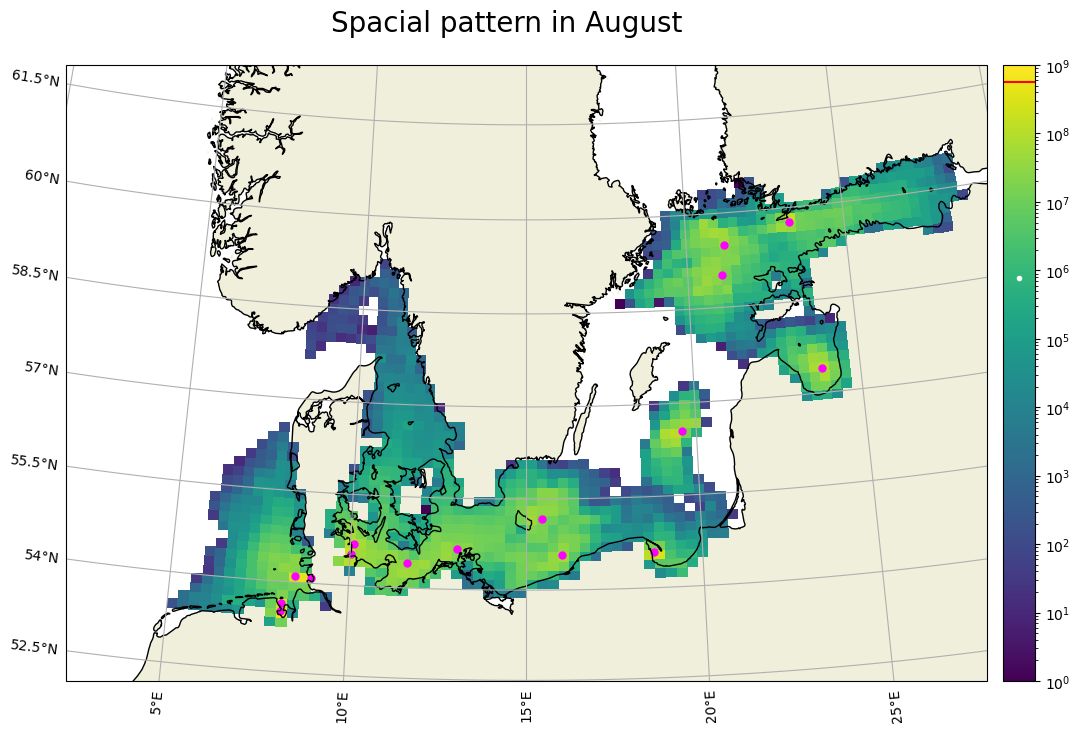

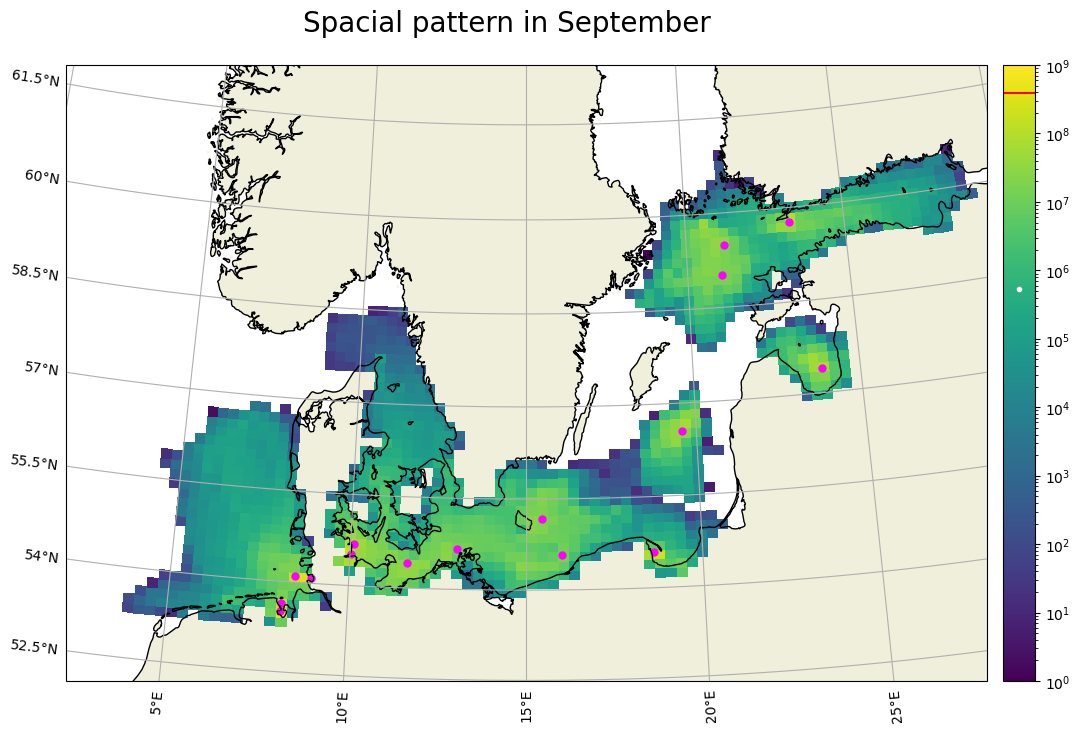

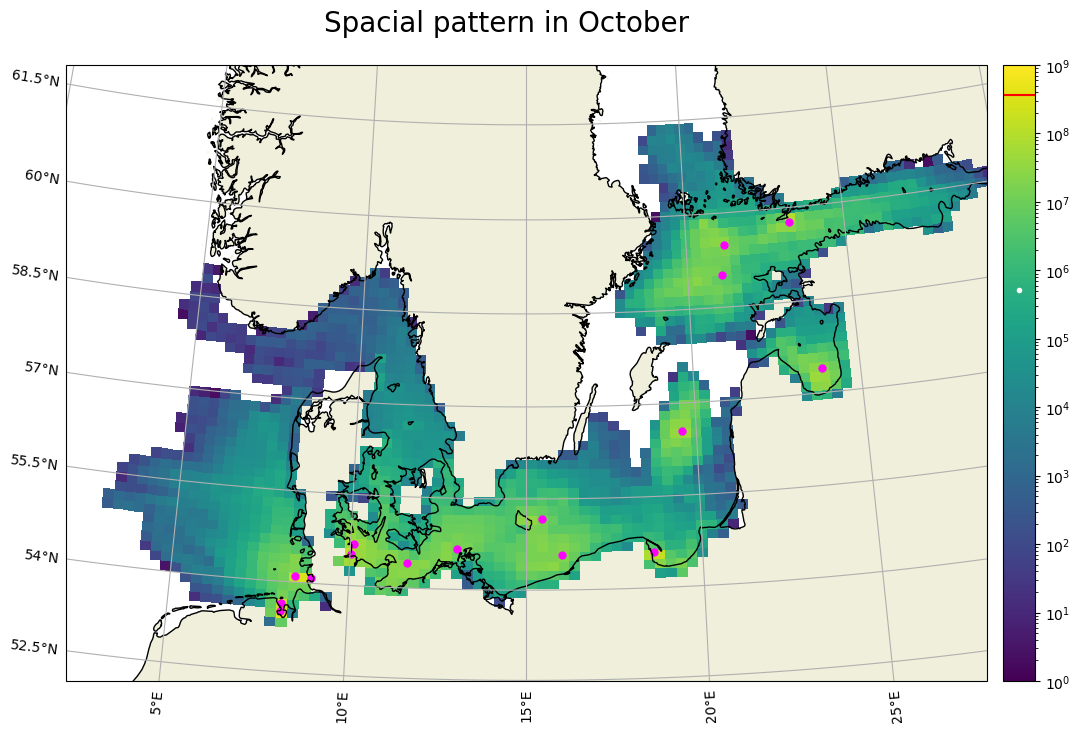

In [34]:
for m in np.arange(6,11):
    heatmap(data=monthly_histogram, month=m, fn=f"Heatmap_allSites_{title_months[m]}.png")

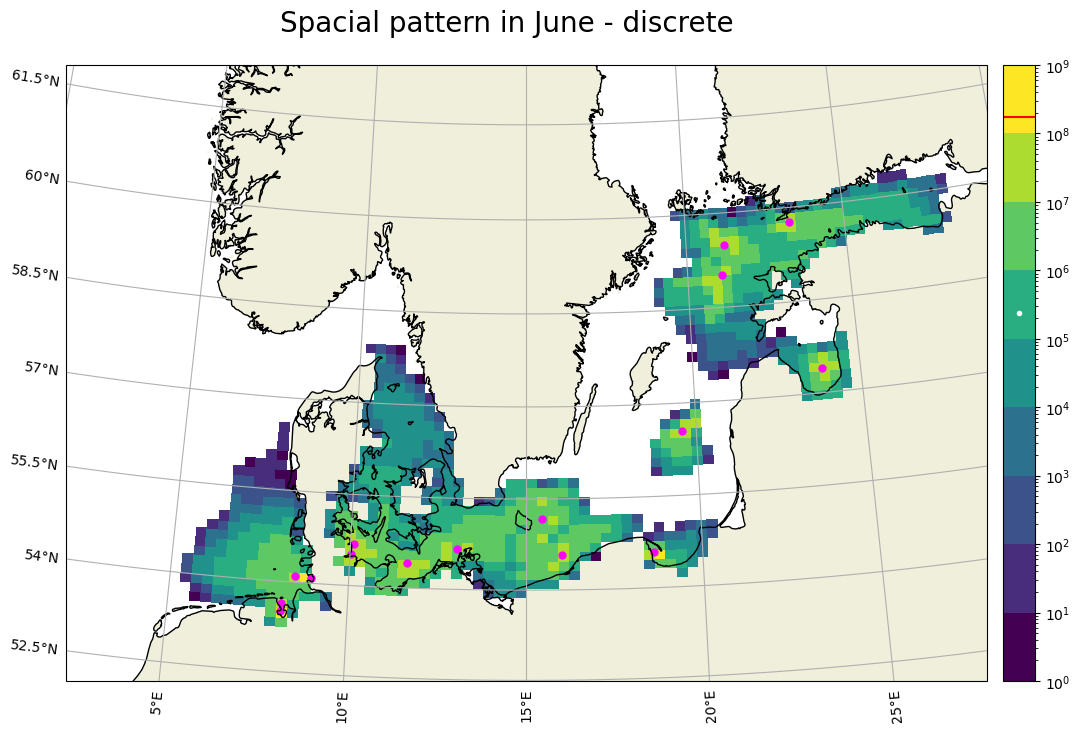

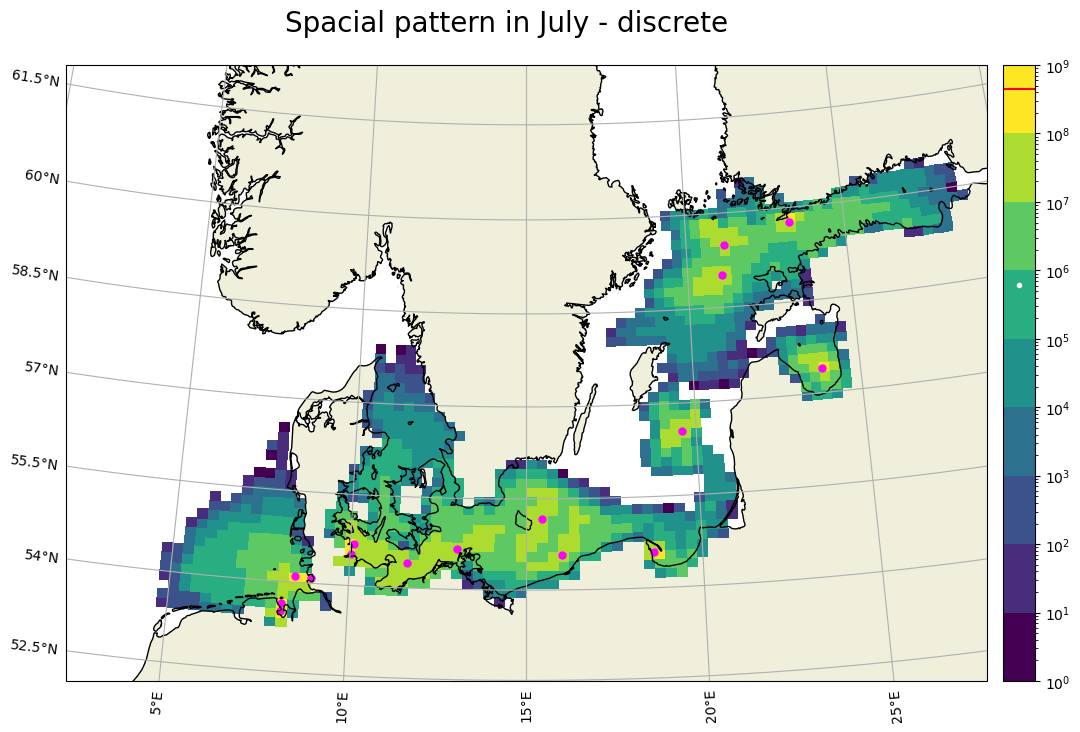

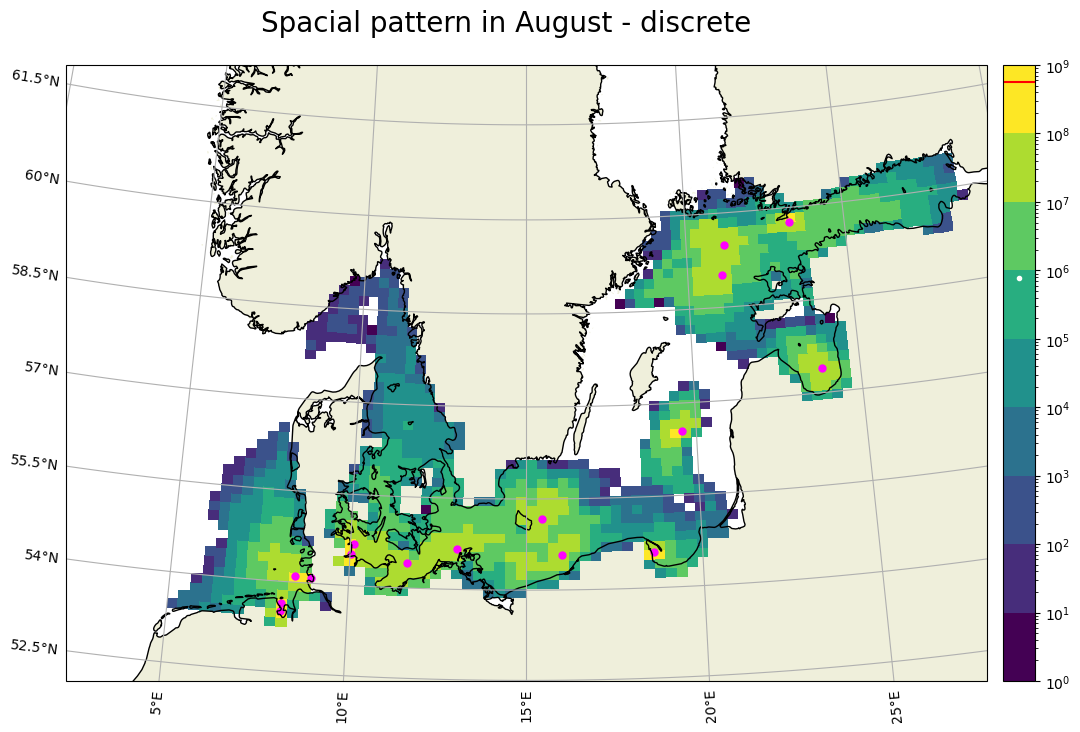

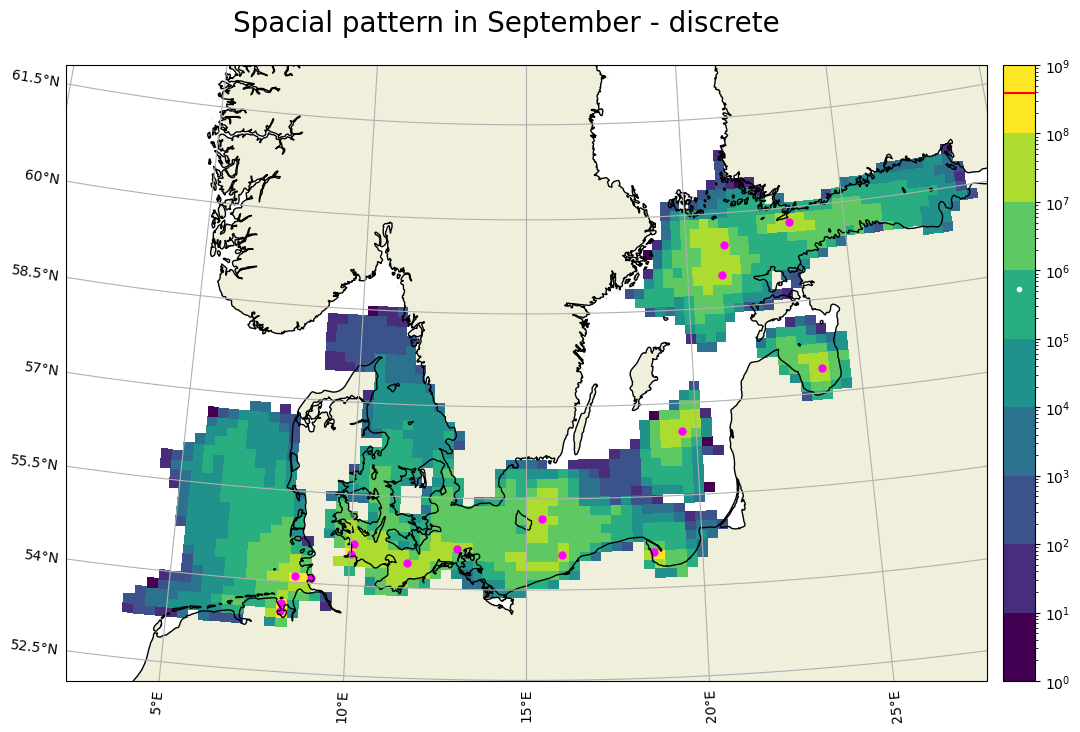

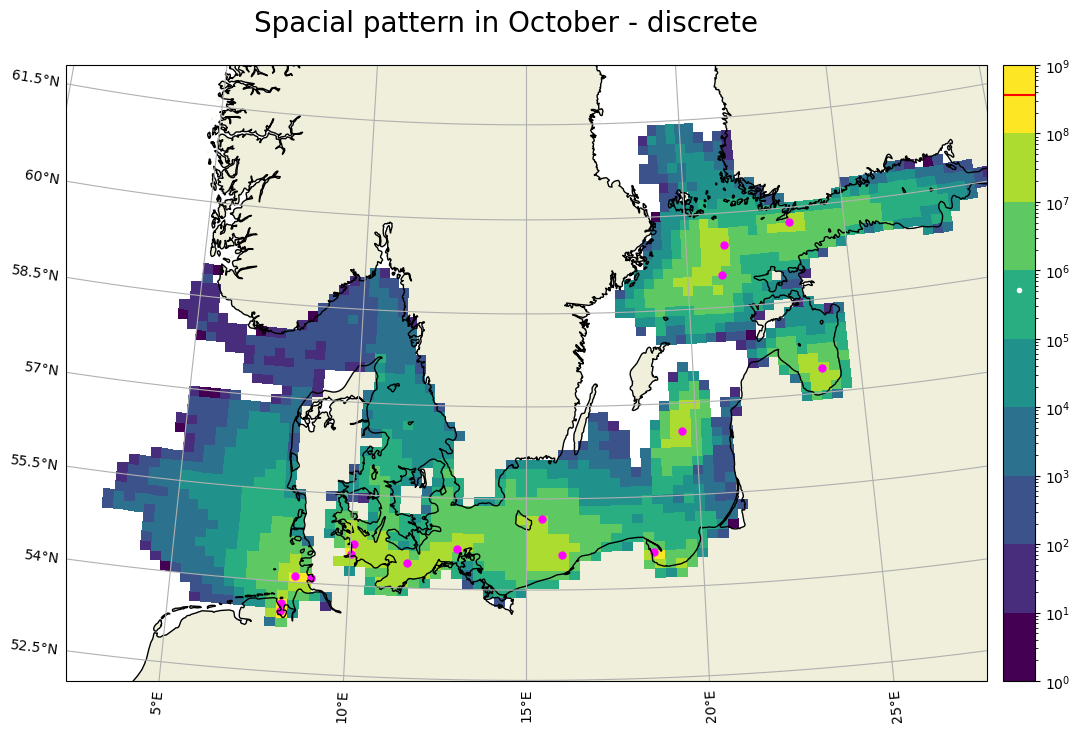

In [35]:
for m in np.arange(6,11):
    heatmap(
        data=monthly_histogram,
        month=m, 
        fn=f"Heatmap_allSites_{title_months[m]}_Discrete.png", 
        isdiscrete=True
    )

### Age

In [36]:
hist_age_file_list = sorted(Path(input_path).glob(f"hist/age/hist2d*"))
print(len(hist_age_file_list))

144


In [37]:
hist_age_raw = np.load(hist_age_file_list[0], allow_pickle=True).all()
age_histogram = {}
for d in np.arange(1,29):
    age_histogram[d] = np.zeros_like(hist_age_raw[1])

for hist_age_file in hist_age_file_list:
    hist = np.load(hist_age_file, allow_pickle=True).all()
    for d, data in hist.items():
        age_histogram[d] = age_histogram[d] + data
for i, hist in age_histogram.items():
    age_histogram[i] = hist.T

In [38]:
# fig = plt.figure(figsize=mapsize)
# fig.suptitle(f"Particlespread over lifespan", size=suptitle_size)
# ax_map = fig.add_subplot(projection=map_projection)
# ax_map.set_extent(extent, PlateCarree())
# ax_map.add_feature(cartopy.feature.LAND)
# ax_map.add_feature(cartopy.feature.COASTLINE)
# ax_map.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
# hist = ax_map.pcolormesh(
#     lonbins, latbins,
#     data,
#     norm=LogNorm(vmin=1, vmax=10**9),
#     transform=PlateCarree(),
#     cmap="viridis",
# )
# map_sites(ax_map)
# make_cbar(fig, ax_map, hist)
# cbar.ax.axhline(data.max(), c='r')
# data[data == 0] = "nan"
# cbar.ax.plot(0.5, np.nanmean(data), 'w.', label="mean")
# cbar.ax.plot(0.5, np.nanmedian(data), 'w_', label="median")
# plt.show()

In [39]:
age_3d = np.zeros((100,100,29))
for d in np.arange(1,29):
    age_3d[:,:,d] = age_histogram[d]

In [40]:
lonbinsage = np.linspace(0,30,nbins)
latbinsage = np.linspace(50,65,nbins)

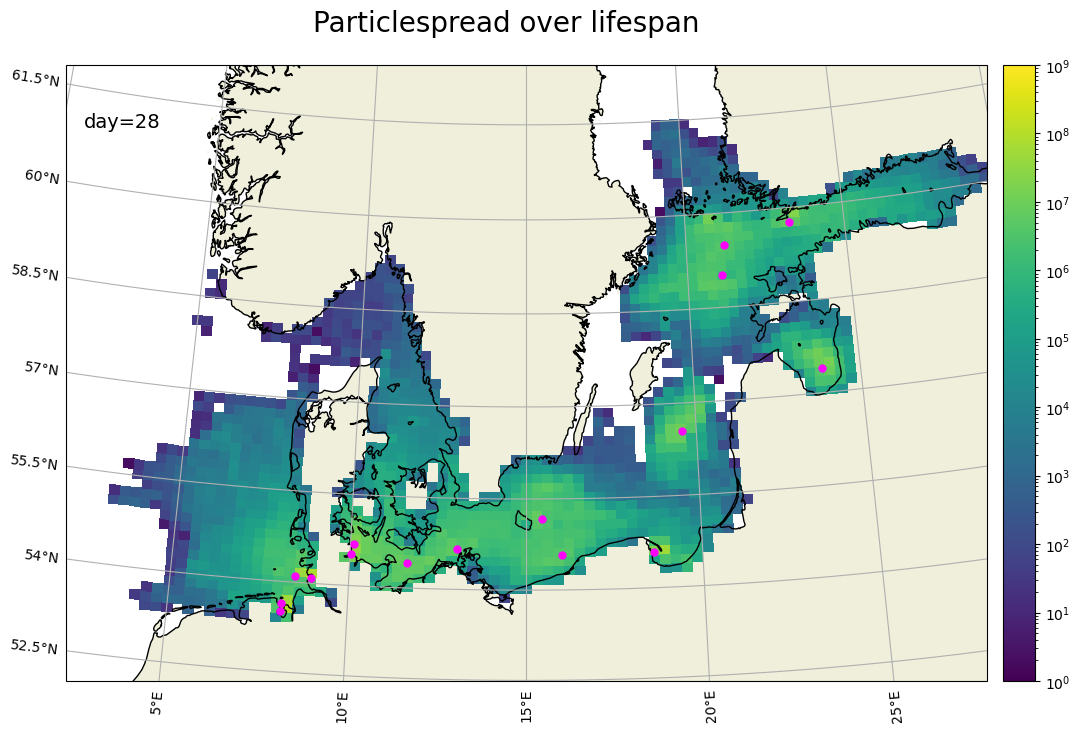

In [41]:
fig = plt.figure(figsize=mapsize)
fig.suptitle(f"Particlespread over lifespan", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
ax_map.scatter(
        lons, lats,
        transform=Geodetic(),
        c="magenta", s=25,
        zorder=100,
    )
hist = ax_map.pcolormesh(
   lonbinsage, latbinsage, 
   age_3d[:-1, :-1, 0], 
   norm=lognorm,
   transform=PlateCarree(),
   cmap='viridis',
   )
make_cbar(fig, ax_map, hist)
time_text = ax_map.text(0.02,0.9,"day=1", transform=ax_map.transAxes, size=14,)

def animate(i):
   time_text.set_text(f"day={i+1}")
   hist.set_array(age_3d[:-1, :-1, i].flatten())

anim = animation.FuncAnimation(fig, animate, interval=200, frames=28)
anim.save(Path(figure_outpath, 'Age_spreading.gif'))
plt.show()

## Sites

### Total

In [42]:
hist_zeros = np.zeros((nbins,nbins))
hist_sites = {}
for s in np.arange(16):
    hist_sites[s] = hist_zeros

for hist_file in hist_total_file_list:
    site = int(str(hist_file)[-6:-4])
    hist_sites[site] = hist_sites[site] + np.load(hist_file)
for i, hist in hist_sites.items():
    hist_sites[i] = hist.T

In [43]:
location_colors = [
    "#2CA02C", "#9467BD", "#9467BD", "#ff00ff",
    "#FF7E0E", "#FFD92F", "#00ff00", "#1F77B4",
    "#D62728", "#FFD92F", "#16BDCF", "#1F77B4",
    "#D62728", "#FFD92F", "#D62728", "#E377C2",
]
location_colors = colors.ListedColormap(location_colors[:-1], "")

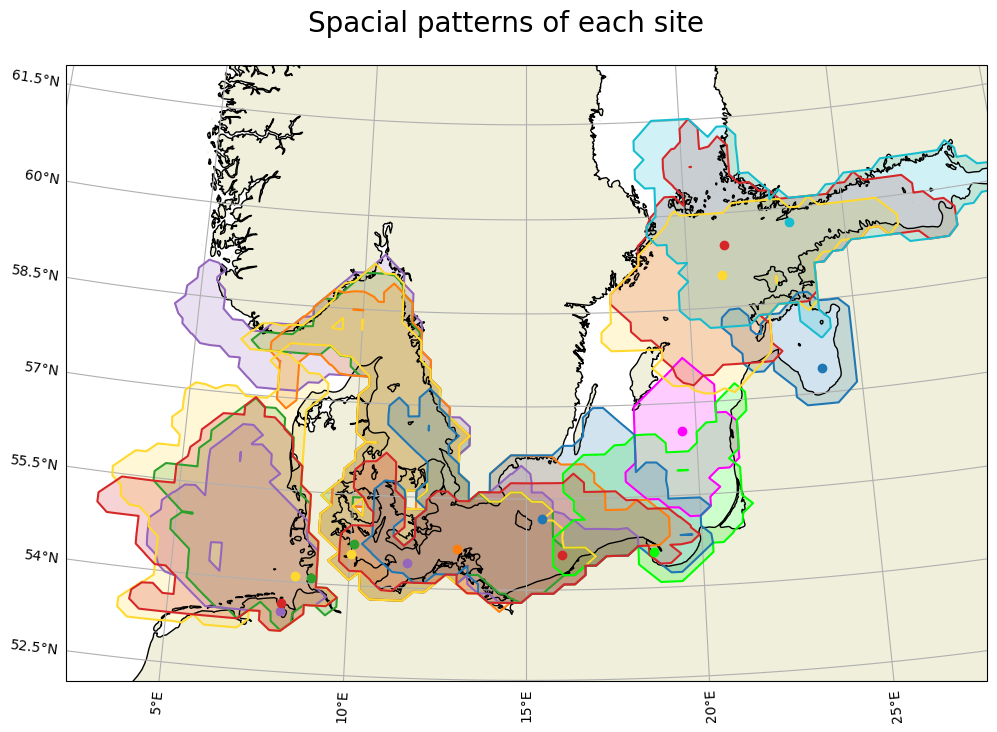

In [44]:
fn = "Spreadmap.png"
fig = plt.figure(figsize=mapsize)
fig.suptitle(
    "Spacial patterns of each site",
    size=suptitle_size, y=0.95,
    )
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
for s, hist in hist_sites.items():
    color = colors.to_rgba_array(location_colors(s-1))
    color_alpha = colors.to_rgba_array(location_colors(s-1))
    color_alpha[0][-1] = 0.2
    cmap = [color_alpha, np.array([1,1,1,0])]
    cmap = colors.ListedColormap(cmap[:-1], "")
    ax_map.contourf(
        lonbins, latbins,
        hist, 
        levels=[1,10**10],
        cmap=cmap,
        transform=PlateCarree(),
    )
    ax_map.contour(
        lonbins, latbins,
        hist, 
        levels=[1,10**10],
        colors=color,
        transform=PlateCarree(),
    )
    ax_map.scatter(
        lons[s], lats[s],
        color=color,
        transform=Geodetic(),
        zorder=100,
    )
# plt.savefig(Path(figure_outpath, fn), format="png")
plt.show()

### Monthly

In [45]:
hist_monthly_file_list = sorted(Path(input_path).glob(f"hist/monthly/hist2d*"))

hist_zeros = np.zeros((nbins,nbins))
hist_sites_monthly = {}
for s in np.arange(16):
    for m in np.arange(6,11):
        hist_sites_monthly[s, m] = hist_zeros
    
for hist_file in hist_monthly_file_list:
    site = int(str(hist_file)[-6:-4])
    hist = np.load(hist_file, allow_pickle=True).all()
    for m, data in hist.items():
        hist_sites_monthly[site, m] = hist_sites_monthly[site, m] + data
for i, hist in hist_sites_monthly.items():
    hist_sites_monthly[i] = hist.T

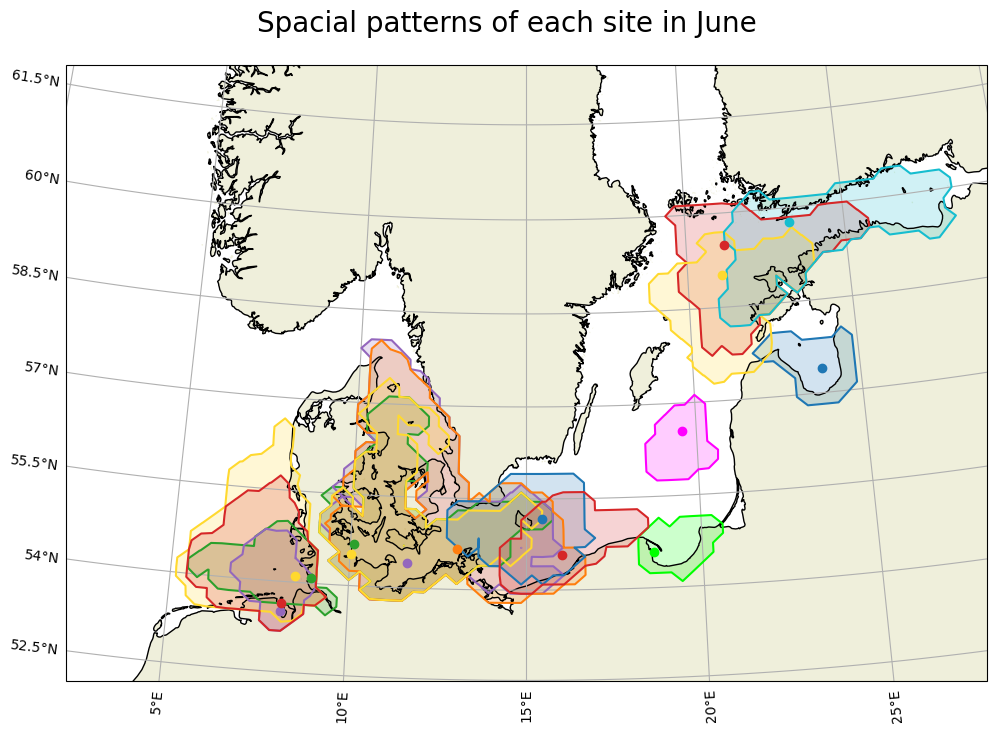

In [46]:
def make_site_spread_map(month, fn=None):
    fig = plt.figure(figsize=mapsize)
    fig.suptitle(
        f"Spacial patterns of each site in {title_months[month]}",
        size=suptitle_size, y=0.95,
        )
    ax_map = fig.add_subplot(projection=map_projection)
    basemap(ax_map)
    for (s, m), hist in hist_sites_monthly.items():
        if m == month:
            color = colors.to_rgba_array(location_colors(s-1))
            color_alpha = colors.to_rgba_array(location_colors(s-1))
            color_alpha[0][-1] = 0.2
            cmap = [
                color_alpha,
                np.array([1,1,1,0]),
            ]
            cmap = colors.ListedColormap(cmap[:-1], "")
            ax_map.contourf(
                lonbins, latbins,
                hist, 
                levels=[1,10**10],
                cmap=cmap,
                transform=PlateCarree(),
            )
            ax_map.contour(
                lonbins, latbins,
                hist, 
                levels=[1,10**10],
                colors=color,
                transform=PlateCarree(),
            )
            ax_map.scatter(
                lons[s], lats[s],
                color=color,
                transform=Geodetic(),
                zorder=100,
            )
    if fn != None:
        plt.savefig(Path(figure_outpath, fn), format="png")
    plt.show()
make_site_spread_map(month = 6)

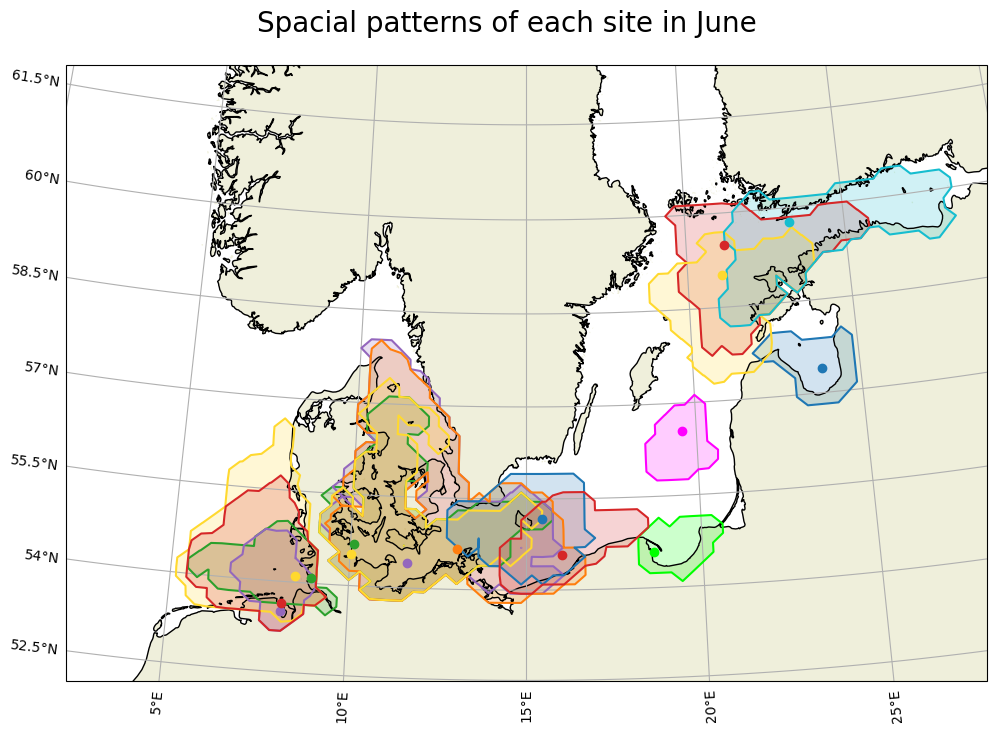

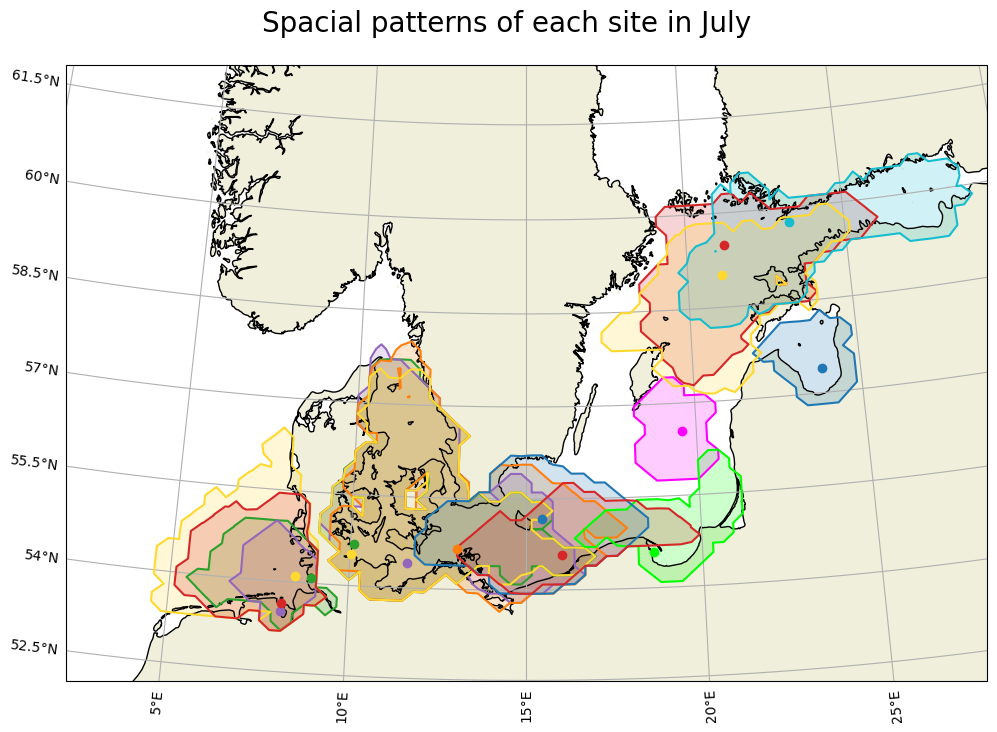

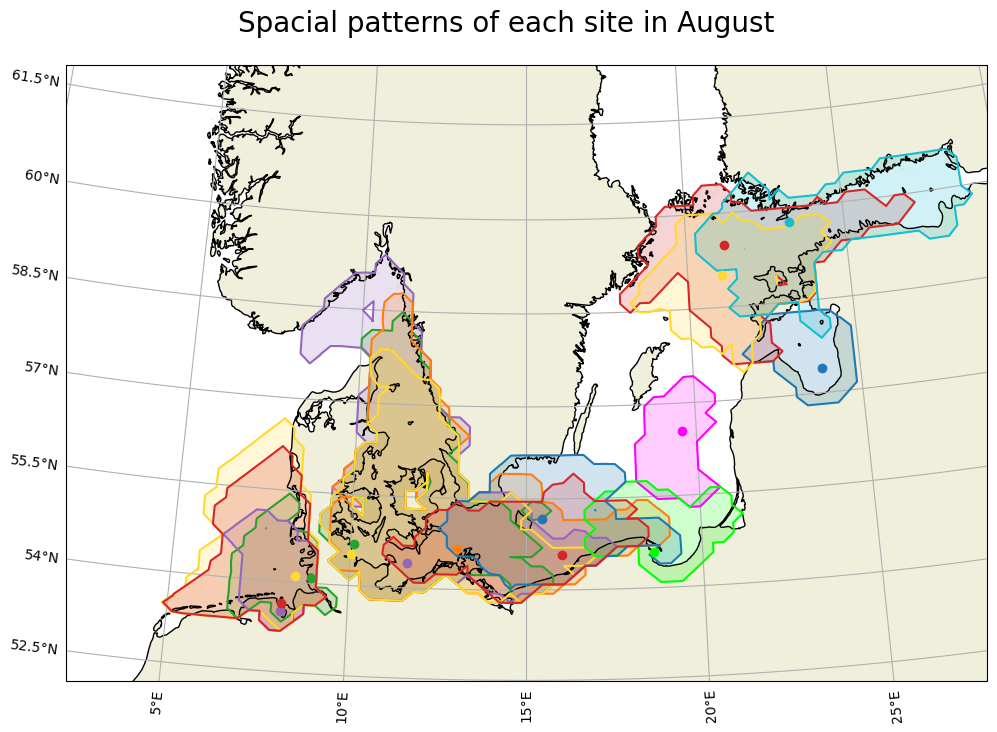

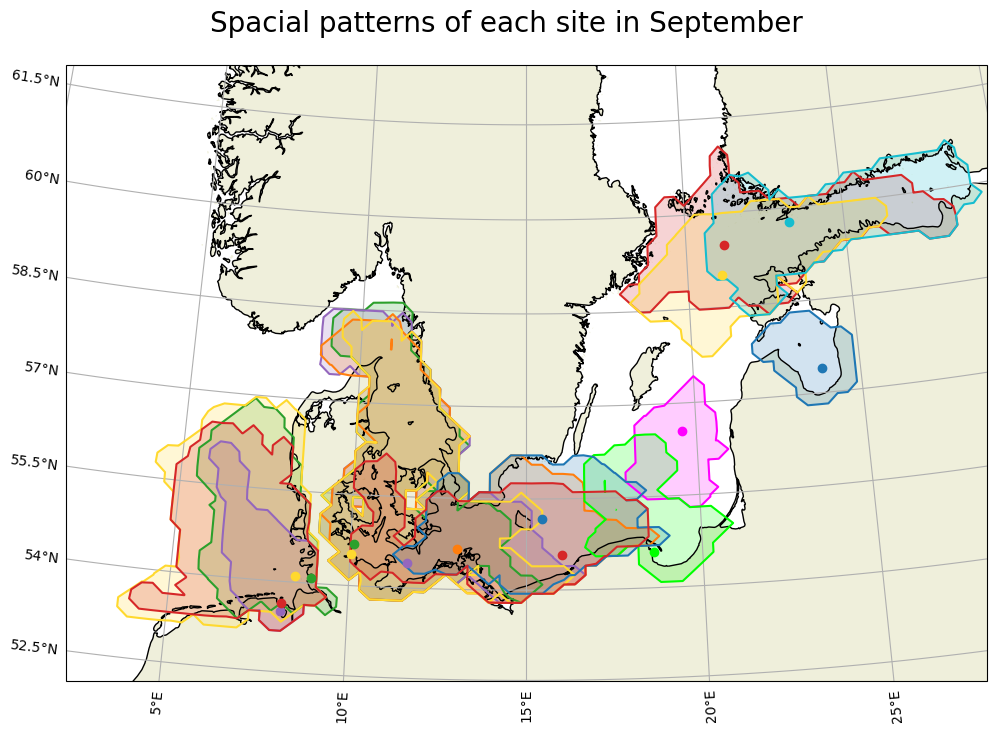

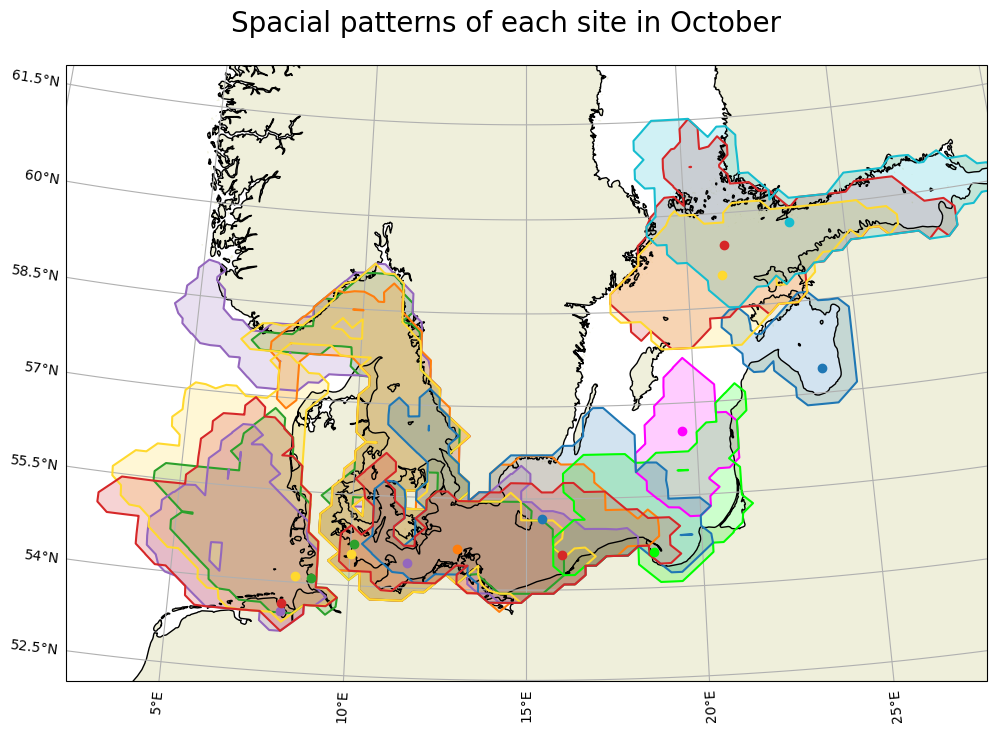

In [47]:
for m in np.arange(6,11):
    make_site_spread_map(
        month = m, 
        fn=f"Spreadmap_{title_months[m]}.png",
        )

## Connectivity Map

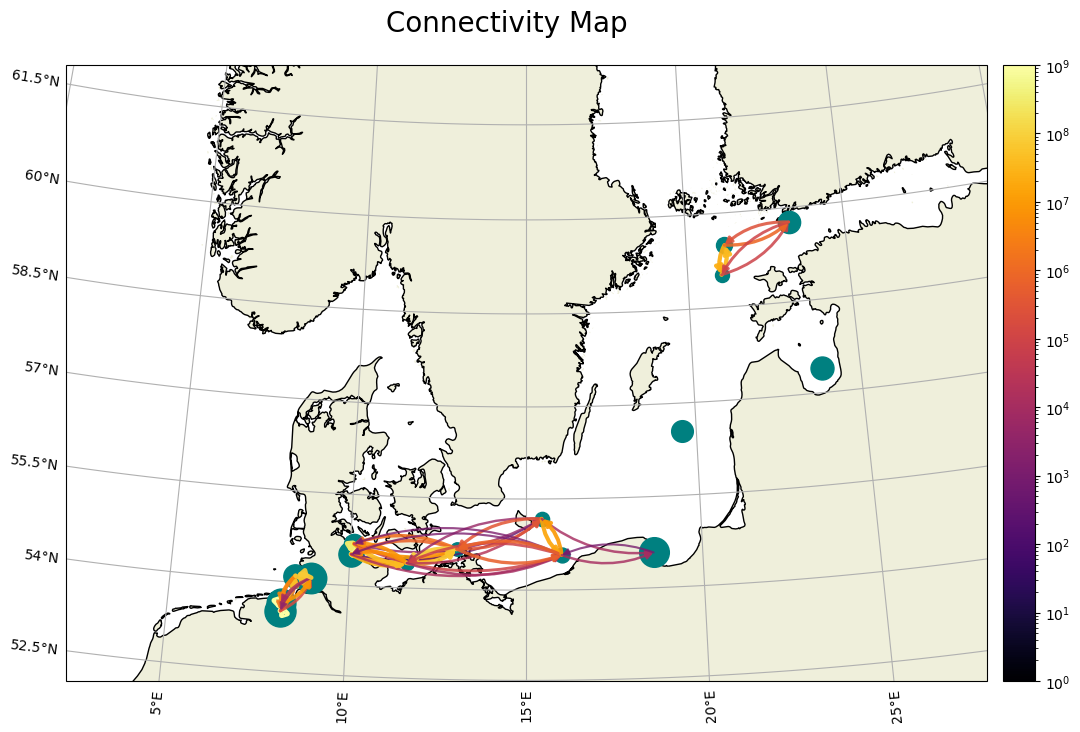

In [49]:
max_connection = df_cmatrix_total.max().max()
fig = plt.figure(figsize=mapsize)
fig.suptitle("Connectivity Map", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
cmap = mpl.colormaps.get_cmap("inferno")

hist = ax_map.pcolormesh(
   lonbinsage, latbinsage, 
   age_3d[:-1, :-1, 0], 
   norm=lognorm,
   transform=PlateCarree(),
   cmap=cmap,
   )
for i in range(len(lons)):
    for j in range(len(lons)):
        start_lon, start_lat = df_locations_sorted.lon[i], df_locations_sorted.lat[i]
        end_lon, end_lat = df_locations_sorted.lon[j], df_locations_sorted.lat[j]
        xyA = map_projection.transform_point(
            start_lon, start_lat, PlateCarree()
            )
        xyB = map_projection.transform_point(
            end_lon, end_lat, PlateCarree()
            )

        n_connections = df_cmatrix_total.iloc[i].iloc[j]
        color = cmap(lognorm(n_connections))
        if n_connections == 0:
            con_alpha = 0
        else:
            con_alpha = (n_connections/max_connection)**(1/60)
            con_lw = (n_connections/max_connection)**(1/15)
            con_size = (n_connections/max_connection)
        if i == j:
            ax_map.scatter(
                start_lon,start_lat,
                s=con_size*500, zorder=100,
                transform=PlateCarree(),
                c="teal",
                )
        else:
            con = ConnectionPatch(
                xyA=xyA, coordsA=ax_map.transData,
                xyB=xyB, coordsB=ax_map.transData,
                zorder=80,
                lw=con_lw*4,
                color=color,
                alpha=con_alpha,
            )
            con.set_arrowstyle("-|>,head_length=0.4,widthB=1")
            con.set_connectionstyle("Arc3,rad=0.2")
            fig.add_artist(con)
        
make_cbar(fig, ax_map, hist)
# plt.savefig(Path(figure_outpath, "ConnectivityMap.jpg"), format="png")
plt.show()

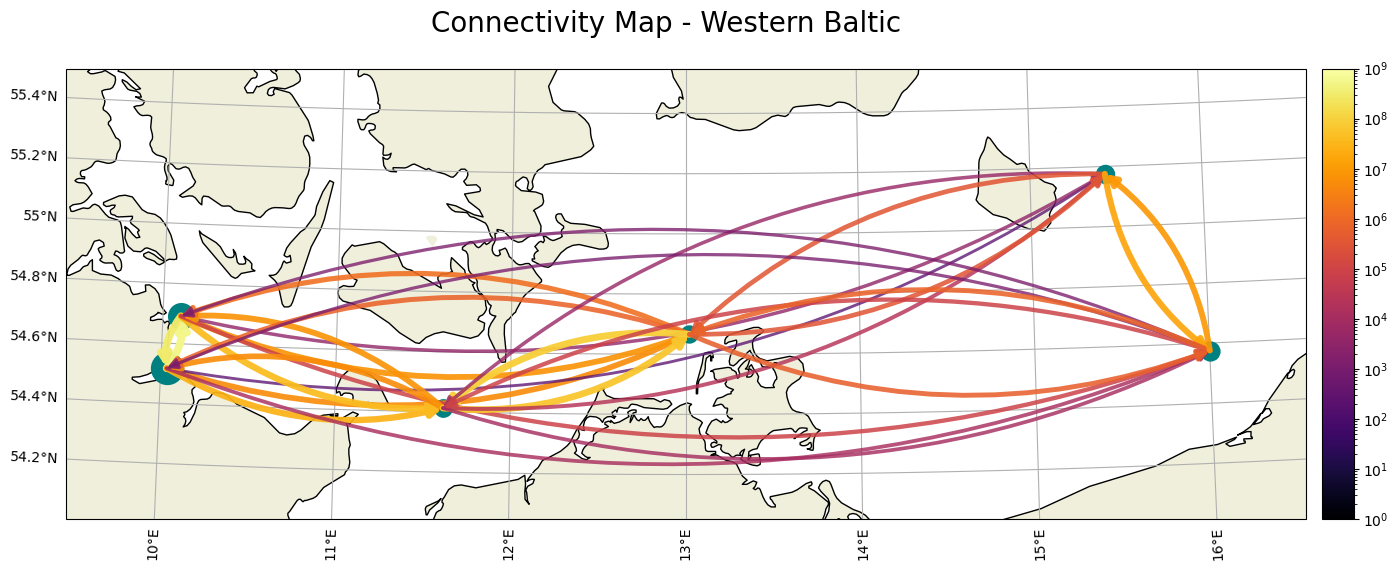

In [50]:
max_connection = df_cmatrix_total.max().max()
close_extent = (7.5,19,53,55.5)
close_extent = (9.5,16.5,54,55.5)
close_map_projection = Stereographic(
    central_longitude=np.mean(close_extent[:2]),
    central_latitude=np.mean(close_extent[2:]),
    )
fig = plt.figure(figsize=mapsize)
fig.suptitle("Connectivity Map - Western Baltic", size=suptitle_size, y=0.85)
ax_map = fig.add_subplot(
    projection=close_map_projection
)
ax_map.set_extent(close_extent, PlateCarree())
ax_map.add_feature(cartopy.feature.LAND)
ax_map.add_feature(cartopy.feature.COASTLINE)
ax_map.gridlines(draw_labels=["left", "bottom"], y_inline=False,)


cmap = mpl.colormaps.get_cmap("inferno")
hist = ax_map.pcolormesh(
   lonbinsage, latbinsage,
   age_3d[:-1, :-1, 0], 
   norm=lognorm,
   transform=PlateCarree(),
   cmap=cmap,
   )
for i in range(len(lons)):
    for j in range(len(lons)):
        start_lon = df_locations_sorted.lon[i]
        start_lat = df_locations_sorted.lat[i]
        end_lon = df_locations_sorted.lon[j]
        end_lat = df_locations_sorted.lat[j]
        if (
            (start_lon > close_extent[0]) and
            (start_lon < close_extent[1]) and
            (end_lon > close_extent[0]) and
            (end_lon < close_extent[1])
        ):
            xyA = close_map_projection.transform_point(
                start_lon, start_lat, PlateCarree()
                )
            xyB = close_map_projection.transform_point(
                end_lon, end_lat, PlateCarree()
                )

            n_connections = df_cmatrix_total.iloc[i].iloc[j]
            norm = LogNorm(vmin=1, vmax=1e9)
            color = cmap(lognorm(n_connections))
            if n_connections == 0:
                con_alpha = 0
            else:
                con_alpha = (n_connections/max_connection)**(1/60)
                con_lw = (n_connections/max_connection)**(1/15)
                con_size = (n_connections/max_connection)
            if i == j:
                ax_map.scatter(
                    start_lon,start_lat,
                    s=con_size*800, zorder=100,
                    transform=PlateCarree(),
                    c="teal",
                    )
            else:
                con = ConnectionPatch(
                    xyA=xyA, coordsA=ax_map.transData,
                    xyB=xyB, coordsB=ax_map.transData,
                    zorder=80,
                    lw=con_lw*6,
                    color=color,
                    alpha=con_alpha,
                )
                con.set_arrowstyle("-|>,head_length=0.6,head_width=0.3")
                con.set_connectionstyle("Arc3,rad=0.2")
                fig.add_artist(con)

make_cbar(fig, ax_map, hist)
plt.savefig(Path(figure_outpath, "ConnectivityMapWestBaltic.jpg"), format="png")
plt.show()

# Pelagic Heatmap

In [43]:
pelagic_hist = xr.open_dataset(Path("output/PelagicConnectivity/ds_pelagicConnectivity_2024_s02.nc"))
pelagic_hist_total = pelagic_hist["1-2-0"].sum(dim=["age", "start_day","time","site"])


In [ ]:
pelagic_hist["1-2-0"]

<xarray.DataArray '1-2-0' (site: 1, age: 28, start_day: 153, time: 225,
                           lon: 120, lat: 40)> Size: 37GB
array([[[[[[ 0., ...,  0.],
           ...,
           [ 0., ...,  0.]],

          ...,

          [[nan, ..., nan],
           ...,
           [nan, ..., nan]]],


         ...,


         [[[nan, ..., nan],
           ...,
           [nan, ..., nan]],

          ...,

          [[ 0., ...,  0.],
           ...,
           [ 0., ...,  0.]]]],



        ...,



        [[[[nan, ..., nan],
           ...,
           [nan, ..., nan]],

          ...,

          [[nan, ..., nan],
           ...,
           [nan, ..., nan]]],


         ...,


         [[[nan, ..., nan],
           ...,
           [nan, ..., nan]],

          ...,

          [[nan, ..., nan],
           ...,
           [nan, ..., nan]]]]]])
Coordinates:
  * lon        (lon) float64 960B 0.125 0.375 0.625 0.875 ... 29.38 29.62 29.88
  * lat        (lat) float64 320B 52.12 52.38 52.62 52.88 ... 61.38 61.62 61.88
  * site       (site) int64 8B 2
  * time       (time) datetime64[ns] 2kB 2024-06-01 ... 2024-10-31T00:00:00.0...
  * age        (age) int64 224B 1 2 3 4 5 6 7 8 9 ... 20 21 22 23 24 25 26 27 28
  * start_day  (start_day) int64 1kB 0 1 2 3 4 5 6 ... 147 148 149 150 151 152

In [ ]:
# a=0
# pelagic_cm = np.zeros((16,16))
# for day in range(4):
#     for age in pelagic_hist.age:
#         for end in pelagic_hist.site:
#             for start in pelagic_hist.site:
#                 try:
#                     val = pelagic_hist.sel(site=end.values, age=age.values).isel(start_day=day).where(
#                         (
#                             (pelagic_hist.sel(site=end.values, age=age.values).isel(start_day=day) != 0) &
#                             (pelagic_hist.sel(site=start.values, age=age.values).isel(start_day=day) != 0)
#                         )
#                     ).sum().to_array().values[0]
#                     pelagic_cm[end,start] += val
#                 except:
#                     # print("no")
#                     a += 1
# print(a)
# matrix = sort_cmatrix(pelagic_cm)